### import library

In [250]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

### import data customer data for understanding 💡

In [251]:
customers = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_customers_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Users\\HOME\\OneDrive\\Desktop\\python learn\\data anylisy\\eda project\\data set\\olist_customers_dataset.csv'

In [ ]:
customers.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
19837,24156a2c9525681a7c62d618bf3a9f94,61e207a0f8285029e97637908aa6f364,36050,juiz de fora,MG
23004,dff76d8f98864a042bde79ce48314dd9,83011c7d99294a16a97db805038e9e9e,4032,sao paulo,SP
14975,d91269dd81b9bce4f785fb94e5189872,a2694c5df9183031534e4dbdd7411377,7942,francisco morato,SP
82047,8201dcb45400a528803f590ee1eb8bc0,ada7f29a80cc8d907661a127454730e3,23030,rio de janeiro,RJ
80565,a9262f07bdf485ee87c6780a830ff83a,bf3d0b96c5568f51f70c45ac9c5f7278,6900,embu-guacu,SP


In [ ]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [ ]:
customers["customer_id"].nunique()

99441

In [ ]:
customers["customer_unique_id"].nunique()

96096

In [ ]:
customer_repeat =(customers.groupby("customer_unique_id")["customer_id"].count().reset_index(name="order_count").sort_values("order_count",ascending=False)
)
customer_repeat = customer_repeat[customer_repeat["order_count"]>1]
customer_repeat.head()

,customer_unique_id,order_count
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7


we understand that customer_unique_id and customer_id column there is customer_unique_id are the id that never change for evry order but customer_id change every order so real customer count is <H4>96096<h4> and the extra 3300 customer_id are repetated order from customer_unique_ids 

In [ ]:
customers.shape

(99441, 5)

In [ ]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [ ]:
customers.duplicated().sum()

np.int64(0)

#### this data set is perfectly fine no need to modify ✅

### import order  dataset to understand customer orders pattern 💡

In [ ]:
orders = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_orders_dataset.csv")

In [ ]:
orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
59489,8c942d6d0cb6781e00df7a3fafc8ef86,a7a0279b817df69edea8249af6e3ea22,delivered,2018-07-31 17:11:15,2018-07-31 17:44:29,2018-08-02 08:23:00,2018-08-06 18:41:00,2018-08-22 00:00:00
70422,d5f7a7805bc55f3aa5f0c267ac2c77ed,c09a03c98715b144a33f291d19c17741,delivered,2017-04-27 10:28:05,2017-04-27 10:43:03,2017-04-28 09:14:07,2017-05-04 21:57:57,2017-06-01 00:00:00
20594,c87e33940b3c077af4e6fbaa166e54bb,0894391273e30b291b1aa54fb3558cf0,delivered,2017-12-15 16:45:36,2017-12-17 17:31:29,2017-12-19 21:36:58,2017-12-20 19:35:11,2018-01-05 00:00:00
14273,16a73b59c868ed5c7152b96b0ebc7693,63e7a08af483dc834e72063957f82e52,delivered,2017-10-18 23:21:35,2017-10-19 23:28:21,2017-10-20 20:42:09,2017-11-01 17:49:38,2017-12-04 00:00:00
92699,828e12bc152ea9891e8941d4530326fd,89a7fcf7fc62e96cd8a92de58f8d035c,delivered,2017-08-12 01:33:51,2017-08-12 15:50:08,2017-08-16 18:52:29,2017-08-24 20:15:49,2017-10-19 00:00:00


In [ ]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [ ]:
orders["order_id"].value_counts().head(10)

order_id
e481f51cbdc54678b7cc49136f2d6af7    1
53cdb2fc8bc7dce0b6741e2150273451    1
47770eb9100c2d0c44946d9cf07ec65d    1
949d5b44dbf5de918fe9c16f97b45f8a    1
ad21c59c0840e6cb83a9ceb5573f8159    1
a4591c265e18cb1dcee52889e2d8acc3    1
136cce7faa42fdb2cefd53fdc79a6098    1
6514b8ad8028c9f2cc2374ded245783f    1
76c6e866289321a7c93b82b54852dc33    1
e69bfb5eb88e0ed6a785585b27e16dbf    1
Name: count, dtype: int64

In [ ]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [ ]:
orders_reat = (orders.groupby("order_id")["customer_id"].count().reset_index(name="order_count").sort_values("order_count",ascending=False))
orders_reat = orders_reat[orders_reat["order_count"]>1]
orders_reat


,order_id,order_count


In [ ]:
merge_col = (customers.merge(orders[["order_id","customer_id"]],on="customer_id",how="left"))
merge_col

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f
...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2


In [ ]:
merge_col.groupby("customer_unique_id")["order_id"].nunique().sort_values(ascending=False).head(10)


customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
63cfc61cee11cbe306bff5857d00bfe4     6
dc813062e0fc23409cd255f7f53c7074     6
de34b16117594161a6a89c50b289d35a     6
Name: order_id, dtype: int64

In [ ]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [ ]:
orders.duplicated().sum()

np.int64(0)

In [ ]:
orders.shape

(99441, 8)

### import order items data set to understand items 💡

In [ ]:
orders_items = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_order_items_dataset.csv")

In [ ]:
orders_items.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
78249,b21727c169d91071518836ff346b0c39,1,dff4c23e8bf1e78f4a793d8f76c7608c,1660ad786c27fd935378b6192a90b417,2018-07-27 17:15:20,130.00,18.71
66388,97bbec866dd969e84e907130cbb2fac9,1,e3968a0d1e607b271be1b000ee1a2d8d,c3cfdc648177fdbbbb35635a37472c53,2017-09-13 23:03:59,194.90,36.72
69001,9d96a9e98c3d858bd5671f4063710829,1,87cc2aef12eddf0b170234138b0946e0,34d1ca11b242c0fee2c834ae8d788566,2017-06-21 21:42:26,185.81,17.06
88503,c8ff0e33e2f8df953767f28065a3a6e0,1,20531b0644a0719b8d506c4db3c56609,ce7d1888639e6fb06b2749cbfdac1ff7,2018-06-17 22:16:20,138.00,59.98
49223,6fd727ab6a5dcb9b6996451d79f12ab8,1,c1617123e66d2491ca93ceadfd36203e,b2479f944e1b90cf8a5de1bbfde284d6,2018-05-09 03:53:15,49.99,13.71


In [ ]:
orders_items["order_id"].nunique()


98666

In [ ]:
orders_items["order_item_id"].nunique()

21

In [ ]:
orders_items["order_item_id"].value_counts().sort_index()

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

In [ ]:
orders_items["order_id"].value_counts().head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
9ef13efd6949e4573a18964dd1bbe7f5    15
73c8ab38f07dc94389065f7eba4f297a    14
9bdc4d4c71aa1de4606060929dee888c    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
3a213fcdfe7d98be74ea0dc05a8b31ae    12
Name: count, dtype: int64

In [ ]:
missing_orders = set(orders_items["order_id"]) - set(orders["order_id"])

len(missing_orders)

0

In [ ]:
orders_without_items = set(orders["order_id"]) - set(orders_items["order_id"])

len(orders_without_items)

775

In [ ]:
orders[orders["order_id"].isin(orders_without_items)]["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [ ]:
orders[
    orders["order_id"].isin(orders_without_items)
    & ~orders["order_status"].isin(["unavailable", "canceled"])
][
    ["order_id", "customer_id", "order_status",
     "order_purchase_timestamp",
     "order_approved_at",
     "order_delivered_carrier_date",
     "order_delivered_customer_date"]
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
7434,b5359909123fa03c50bdb0cfed07f098,438449d4af8980d107bf04571413a8e7,created,2017-12-05 01:07:52,NaN,NaN,NaN
9238,dba5062fbda3af4fb6c33b1e040ca38f,964a6df3d9bdf60fe3e7b8bb69ed893a,created,2018-02-09 17:21:04,NaN,NaN,NaN
21441,7a4df5d8cff4090e541401a20a22bb80,725e9c75605414b21fd8c8d5a1c2f1d6,created,2017-11-25 11:10:33,NaN,NaN,NaN
23254,a68ce1686d536ca72bd2dadc4b8671e5,d7bed5fac093a4136216072abaf599d5,shipped,2016-10-05 01:47:40,2016-10-07 03:11:22,2016-11-07 16:37:37,NaN
55086,35de4050331c6c644cddc86f4f2d0d64,4ee64f4bfc542546f422da0aeb462853,created,2017-12-05 01:07:58,NaN,NaN,NaN
57591,2ce9683175cdab7d1c95bcbb3e36f478,b2d7ae0415dbbca535b5f7b38056dd1f,invoiced,2016-10-05 21:03:33,2016-10-06 07:46:39,NaN,NaN
58958,90ab3e7d52544ec7bc3363c82689965f,7d61b9f4f216052ba664f22e9c504ef1,created,2017-11-06 13:12:34,NaN,NaN,NaN
69926,e04f1da1f48bf2bbffcf57b9824f76e1,0d00d77134cae4c58695086ad8d85100,invoiced,2016-10-05 13:22:20,2016-10-06 15:51:38,NaN,NaN


In [ ]:
orders_items["price"].sum()

np.float64(13591643.7)

In [ ]:
orders_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [ ]:
orders_items["product_id"].duplicated().sum()

np.int64(79699)

In [ ]:
orders_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [ ]:
orders_items.duplicated().sum()

np.int64(0)

In [ ]:
orders_items.shape

(112650, 7)

#### My understanding 
orders and order_items have different content . orders contains one record per order in other hand  order_items contains one record per item within an order. Therefore the number of rows does not need to match between the two tables. All 98,666 orders represented in order_items exist in the orders table and There are 775 orders without item records .most of which are unavailable or canceled

### import order payment data set to understand payment of orders 💡

In [ ]:
payments = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_order_payments_dataset.csv")

In [ ]:
payments.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
25090,4e279bc55cb8b7abc5a2c1ecdcb6b08e,1,credit_card,10,221.79
36884,47efcc8c3c3a6011c15cbff901605841,1,credit_card,1,45.69
5326,d9f085069cebe18379f8a966f47e4cbe,1,credit_card,1,43.10
44850,99d738d6bfcf410fa6924ed854246917,1,boleto,1,960.49
26497,8d4bf0250a288cb514e50be83d8d6cd1,1,boleto,1,133.76


In [ ]:
payments["payment_value"].sum()

np.float64(16008872.120000001)

In [ ]:
orders["order_id"].nunique()

99441

In [ ]:
payments["order_id"].nunique()

99440

In [ ]:
payments["order_id"].value_counts().head()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
Name: count, dtype: int64

In [ ]:
payments["payment_sequential"].value_counts().sort_index()

payment_sequential
1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
16        6
17        6
18        6
19        6
20        4
21        4
22        3
23        2
24        2
25        2
26        2
27        1
28        1
29        1
Name: count, dtype: int64

In [ ]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [ ]:
payments["payment_type"].value_counts(normalize=True) * 100

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

In [ ]:
payments["payment_sequential"].describe()

count    103886.000000
mean          1.092679
std           0.706584
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          29.000000
Name: payment_sequential, dtype: float64

In [ ]:
payments["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [ ]:
payments[payments["payment_installments"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [ ]:
payments[["order_id", "payment_sequential"]].duplicated().sum()

np.int64(0)

In [ ]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [ ]:
payments[payments["payment_value"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [ ]:

payments[payments["payment_value"] == 0]["payment_type"].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

In [ ]:
orders_without_payments = set(orders["order_id"])-set( payments["order_id"])
len(orders_without_payments)

1

In [ ]:
missing_payment_order = list(orders_without_payments)[0]

orders[
    orders["order_id"] == missing_payment_order
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00


In [ ]:
orders_items[
    orders_items["order_id"] == missing_payment_order
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
84389,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84390,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84391,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83


In [ ]:
payments[
    payments["order_id"] == missing_payment_order
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [ ]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [ ]:
payments.shape

(103886, 5)

In [ ]:
payments.duplicated().sum()

np.int64(0)

Payment Dataset Findings

The payment table contains 103,886 payment records reation with 99,440 distinct orders.<br>
Multiple payment records can belong to the same order shown by payment_sequential.<br>
The combination of order_id and payment_sequential is unique.<br>
Credit card is the dominant payment method by record count.<br>
Two credit-card records contain zero installments despite having positive payment values,shown some data-quality anomalies.<br>
Zero-value payment records exist, primarily associated with voucher and undefined payment types these should be investigated rather than automatically removed.<br>
One delivered order exists in the orders table without a corresponding payment record and should be cross check .

#### import order_reviews data to understand reviews of data 💡

In [ ]:
order_reviews = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_order_reviews_dataset.csv")

In [ ]:
order_reviews.sample(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
37308,ab2f1d8caf8fe553f13dbd72065a5a71,d2d134bb44882b886b6e6a2c0af66e6e,5,NaN,loja cumpri o prazo,2017-12-16 00:00:00,2017-12-18 19:17:56
57969,f36b28099878676e2c6d2dc0f7773d77,eeba00e11fa68a44e8f8ea73e40da5b7,4,NaN,NaN,2018-01-09 00:00:00,2018-01-10 13:38:02
99176,d8ab64a06366d369a9cdbed694e7ee93,c3b620f59a689c3ca6b5884d2f6c6ac8,5,super recomendo,NaN,2018-06-13 00:00:00,2018-07-02 22:17:07
69782,c2c86a79b7b893cf1b4200c1045325b6,85eeda44e93bdd0ac057cdf18179d693,5,NaN,NaN,2018-08-25 00:00:00,2018-08-26 21:24:35
88458,0ca7ae8464d1afe276c8df6cf26590ca,830d2f9316703d28776bd868412fb961,5,NaN,NaN,2017-05-23 00:00:00,2017-07-06 01:07:13


In [ ]:
order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [ ]:
order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"])

order_reviews["review_answer_timestamp"] = pd.to_datetime(order_reviews["review_answer_timestamp"])

In [ ]:
order_reviews["order_id"].nunique()

98673

In [ ]:
order_reviews["order_id"].value_counts().head(10)

order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
169d7e0fd71d624d306f132acd791cbe    2
1c308eca3f339414a92e518e2a2e5ee9    2
2002ea16e75277eaa0b5d78632048540    2
1d297b4800ed1a3c5b0944d84c01ee99    2
0176a6846bcb3b0d3aa3116a9a768597    2
Name: count, dtype: int64

In [ ]:
order_reviews["order_id"].value_counts().value_counts().sort_index()

count
1    98126
2      543
3        4
Name: count, dtype: int64

In [ ]:
order_reviews["review_id"].nunique()

98410

In [ ]:
order_reviews["review_id"].value_counts().head(10)

review_id
c444278834184f72b1484dfe47de7f97    3
308316408775d1600dad81bd3184556d    3
2d6ac45f859465b5c185274a1c929637    3
3415c9f764e478409e8e0660ae816dd2    3
4219a80ab469e3fc9901437b73da3f75    3
e44840754f12fad2b8646712121b349a    3
ddc52555ca27b0fe67d5255147682d2d    3
7b606b0d57b078384f0b58eac1d41d78    3
4d0e6dd087008d1f992d25ef6e1f619f    3
08528f70f579f0c830189efc523d2182    3
Name: count, dtype: int64

In [ ]:
order_reviews["review_id"].value_counts().value_counts().sort_index()

count
1    97621
2      764
3       25
Name: count, dtype: int64

In [ ]:
order_reviews[["review_id", "order_id"]].duplicated().sum()

np.int64(0)

In [ ]:
order_reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [ ]:
order_reviews["review_score"].value_counts(normalize=True).sort_index() * 100

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

In [ ]:
order_reviews.groupby("order_id")["review_score"].mean()

order_id
00010242fe8c5a6d1ba2dd792cb16214    5.0
00018f77f2f0320c557190d7a144bdd3    4.0
000229ec398224ef6ca0657da4fc703e    5.0
00024acbcdf0a6daa1e931b038114c75    4.0
00042b26cf59d7ce69dfabb4e55b4fd9    5.0
                                   ... 
fffc94f6ce00a00581880bf54a75a037    5.0
fffcd46ef2263f404302a634eb57f7eb    5.0
fffce4705a9662cd70adb13d4a31832d    5.0
fffe18544ffabc95dfada21779c9644f    5.0
fffe41c64501cc87c801fd61db3f6244    5.0
Name: review_score, Length: 98673, dtype: float64

In [ ]:
order_reviews.shape


(99224, 7)

In [ ]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [ ]:
order_reviews["review_comment_message"].notna().sum()

np.int64(40977)

In [ ]:
order_reviews.duplicated().sum()

np.int64(0)

In [ ]:
missing_review_orders = set(order_reviews["order_id"]) - set(orders["order_id"])

len(missing_review_orders)

0

In [ ]:
orders_without_reviews = set(orders["order_id"]) - set(order_reviews["order_id"])

len(orders_without_reviews)

768

In [ ]:
review_counts = order_reviews["review_id"].value_counts()

repeated_reviews = review_counts[review_counts > 1].index

order_reviews[
    order_reviews["review_id"].isin(repeated_reviews)
].sort_values("review_id").head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44


In [ ]:
order_reviews[
    order_reviews["review_id"].isin(repeated_reviews)
][["review_id", "order_id"]].drop_duplicates().head(20)

,review_id,order_id
200,28642ce6250b94cc72bc85960aec6c62,e239d280236cdd3c40cb2c033f681d1c
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe
346,f4d74b17cd63ee35efa82cd2567de911,f269e83a82f64baa3de97c2ebf3358f6
360,ecbaf1fce7d2c09bfab46f89065afeaf,2451b9756f310d4cff5c7987b393870d
393,6b1de94de0f4bd84dfc4136818242faa,92acf87839903a94aeca0e5040d99acb
433,957011305e7a4b6c8a266eeeb8e0316d,54b4da510fed5dc3cf3e7a8e50a5f224
508,b34f4a786bf00b7c8486141ba482783b,b2501eb5c292d415f52576b3d4b5de74
661,d433c252647c51309432ca0b763f969b,448795135b904d057254f5fd0d5a6a4c
723,5f35bbde2b32b8617aab15b7a9a0ae24,ba568688e2f462d7c44a3fdc62e6456f
764,c5976a5a98e854fb23d7e03c6754ae60,2002ea16e75277eaa0b5d78632048540


<h3>Data finding </h3>
The order_reviews dataset contains 99,224 review records covering 98,673 unique orders.<br>
The table has no completely duplicated rows, and all review order_id values have corresponding orders. Both review_id and order_id can occur multiple times, while the (review_id, order_id) combination is unique in the available data.<br>
Review scores are complete, with 5-star ratings representing 57.78% of records.<br>
Review text fields contain substantial missing values, which are treated as optional customer-provided information rather than automatically classified as data errors.<br>
A total of 768 orders have no corresponding review record. This table can therefore be used to analyze customer satisfaction, review behavior, and relationships between customer ratings and operational/product characteristics.

### importing location to understand were most people from 💡

In [ ]:
location = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_geolocation_dataset.csv")

In [ ]:
location.sample(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
209693,8573,-23.493492,-46.345641,itaquaquecetuba,SP
949237,91510,-30.066092,-51.176115,porto alegre,RS
151915,6170,-23.544174,-46.806469,osasco,SP
630336,37472,-22.120635,-45.125532,carmo de minas,MG
65074,3736,-23.508261,-46.515517,sao paulo,SP


In [ ]:
location.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [ ]:
location["geolocation_zip_code_prefix"].nunique()

19015

In [ ]:
location[["geolocation_lat","geolocation_lng"]].describe()

,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06
mean,-2.117615e+01,-4.639054e+01
std,5.715866e+00,4.269748e+00
min,-3.660537e+01,-1.014668e+02
25%,-2.360355e+01,-4.857317e+01
50%,-2.291938e+01,-4.663788e+01
75%,-1.997962e+01,-4.376771e+01
max,4.506593e+01,1.211054e+02


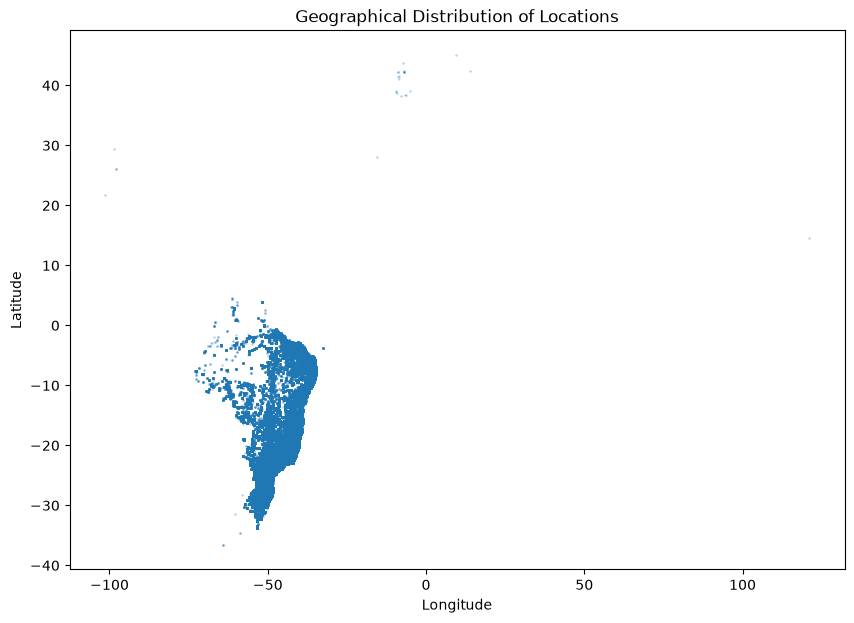

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    location["geolocation_lng"],
    location["geolocation_lat"],
    s=1,
    alpha=0.2
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Locations")

plt.show()

In [ ]:
location.groupby("geolocation_zip_code_prefix")[["geolocation_lat","geolocation_lng"]].nunique().head(10)

,geolocation_lat,geolocation_lng
geolocation_zip_code_prefix,,
1001,10,10
1002,6,6
1003,10,10
1004,14,14
1005,11,11
1006,7,7
1007,15,15
1008,12,12
1009,7,7


In [ ]:
location["geolocation_city"].value_counts().head(10)

geolocation_city
sao paulo                135800
rio de janeiro            62151
belo horizonte            27805
são paulo                 24918
curitiba                  16593
porto alegre              13521
salvador                  11865
guarulhos                 11340
brasilia                  10470
sao bernardo do campo      8112
Name: count, dtype: int64

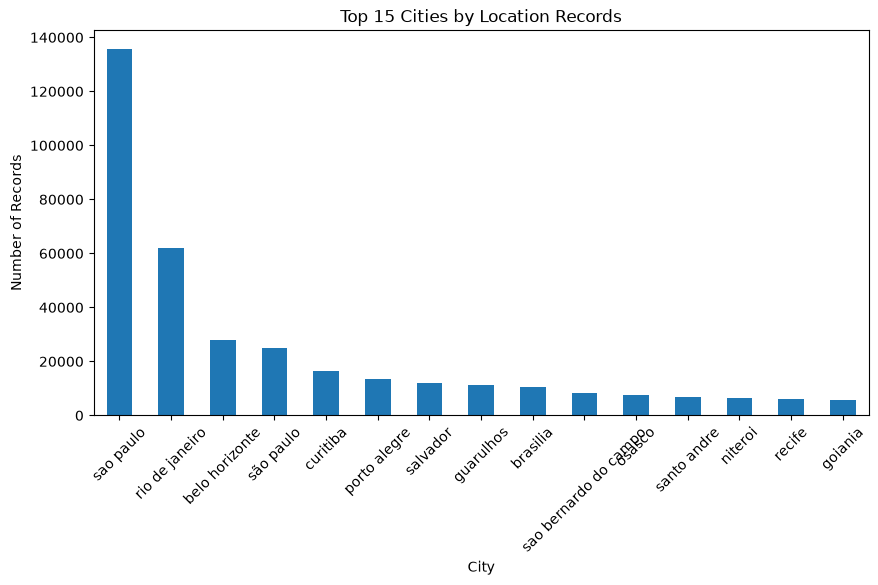

In [ ]:
location["geolocation_city"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 15 Cities by Location Records")
plt.xlabel("City")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()

In [ ]:
location["geolocation_state"].value_counts(normalize=True).mul(100).round(2)

geolocation_state
SP    40.42
MG    12.63
RJ    12.11
RS     6.18
PR     5.78
SC     3.83
BA     3.60
GO     2.01
ES     1.67
PE     1.64
DF     1.30
MT     1.20
CE     1.17
PA     1.09
MS     1.04
MA     0.79
PB     0.55
RN     0.50
PI     0.45
AL     0.42
TO     0.36
SE     0.36
RO     0.35
AM     0.24
AC     0.13
AP     0.09
RR     0.06
Name: proportion, dtype: float64

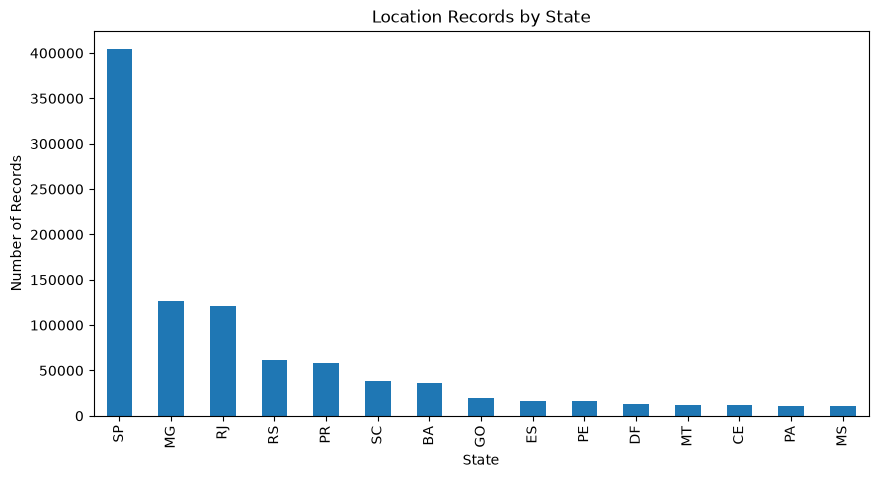

In [ ]:
location["geolocation_state"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Location Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")

plt.show()

In [ ]:
location.groupby("geolocation_state")["geolocation_city"].nunique().sort_values(ascending=True).head(20)

geolocation_state
RR     14
AP     17
DF     28
AC     34
AM     74
RO     83
SE     96
AL    130
MS    133
ES    160
TO    173
MT    213
RN    214
PA    219
RJ    245
PB    254
CE    260
PE    267
PI    278
MA    299
Name: geolocation_city, dtype: int64

In [ ]:
location.duplicated().sum()

np.int64(261831)

In [ ]:
location.shape

(1000163, 5)

#### this data is prefectily fine

### importing seller data to undersatnd sellers pattern 💡

In [ ]:
sellers = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_sellers_dataset.csv")

In [ ]:
sellers.sample(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
3021,31da954dc0855f2495c6310f70a2f931,13601,araras,SP
1076,efff9341f3f8f5237b44ff67ed36a7bf,29090,vitoria,ES
496,6a38087bc8ad4f89ff453561005f6dea,75123,anapolis,GO
486,70f84699be677ec988d1fa824aef7d90,35700,sete lagoas,MG
2773,725c32fa80c2faacc4fc88450d27314e,3320,sao paulo,SP


In [ ]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [ ]:
sellers["seller_id"].nunique()

3095

In [ ]:
sellers["seller_city"].nunique()

611

In [ ]:
sellers["seller_state"].nunique()

23

In [ ]:
sellers["seller_zip_code_prefix"].nunique()

2246

In [ ]:
sellers['seller_city'].value_counts()

seller_city
sao paulo                 694
curitiba                  127
rio de janeiro             96
belo horizonte             68
ribeirao preto             52
                         ... 
aparecida de goiania        1
bandeirantes                1
vitoria de santo antao      1
palotina                    1
leme                        1
Name: count, Length: 611, dtype: int64

In [ ]:
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [ ]:
sellers["seller_state"].value_counts(normalize=True).mul(100).round(2)

seller_state
SP    59.74
PR    11.28
MG     7.88
SC     6.14
RJ     5.53
RS     4.17
GO     1.29
DF     0.97
ES     0.74
BA     0.61
CE     0.42
PE     0.29
PB     0.19
RN     0.16
MS     0.16
MT     0.13
RO     0.06
SE     0.06
AC     0.03
PI     0.03
MA     0.03
AM     0.03
PA     0.03
Name: proportion, dtype: float64

In [ ]:
sellers.groupby("seller_state")["seller_id"].nunique().sort_values(ascending=False).head(10)

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: seller_id, dtype: int64

In [ ]:
sellers.groupby("seller_city")["seller_id"].nunique().sort_values(ascending=False).head(10)

seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: seller_id, dtype: int64

In [ ]:
sellers.duplicated().sum()

np.int64(0)

<h3>data understanding</h3>
São Paulo (SP) dominates the seller network.Almost 60% of all sellers are located in SP.The next largest state, PR has only 11.28%.

#### importing product data to understand products list 💡

In [ ]:
products = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\olist_products_dataset.csv")

In [ ]:
products.sample(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
22770,596faa581e9b1ca7d28a1c0777a8423b,brinquedos,33.0,739.0,3.0,500.0,20.0,20.0,20.0
7031,7b22327a8222cb724f17c3a0aa392517,esporte_lazer,37.0,685.0,1.0,925.0,32.0,30.0,27.0
6229,993ac19aa975075775c16ba15426f8be,informatica_acessorios,52.0,1731.0,4.0,9600.0,52.0,19.0,51.0
101,a2e2851eae0aebb8ee4df32348b42e2b,informatica_acessorios,59.0,504.0,3.0,367.0,16.0,4.0,11.0
5601,73258e01fadbaf7648577beb152e1320,informatica_acessorios,50.0,835.0,1.0,250.0,20.0,20.0,20.0


In [ ]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [ ]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products["product_id"].nunique()

32951

In [ ]:
products["product_photos_qty"].value_counts().sort_index()

product_photos_qty
1.0     16489
2.0      6263
3.0      3860
4.0      2428
5.0      1484
6.0       968
7.0       343
8.0       192
9.0       105
10.0       95
11.0       46
12.0       35
13.0        9
14.0        5
15.0        8
17.0        7
18.0        2
19.0        1
20.0        1
Name: count, dtype: int64

In [ ]:
products["product_category_name"].value_counts()

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

In [ ]:
products["product_category_name"].value_counts(normalize=True).mul(100).round(2)

product_category_name
cama_mesa_banho                  9.37
esporte_lazer                    8.86
moveis_decoracao                 8.22
beleza_saude                     7.56
utilidades_domesticas            7.22
                                 ... 
fashion_roupa_infanto_juvenil    0.02
casa_conforto_2                  0.02
pc_gamer                         0.01
seguros_e_servicos               0.01
cds_dvds_musicais                0.00
Name: proportion, Length: 73, dtype: float64

In [ ]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [ ]:
products[
    products["product_category_name"].isna()
].isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [ ]:
products[[
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products.shape

(32951, 9)

In [ ]:
products.duplicated().sum()

np.int64(0)

<h3 >Data Understanding </h3>
The Products table represents the product catalog of the marketplace. <br>
It contains 32,951 unique products across 73 categories, with information about category, name/description length, number of photos, weight, and physical dimensions. ,<br>
Most products have 1–2 photos. Product categories are unevenly distributed, with a few categories containing a large share of products.<br>
Physical dimensions have very few missing values, while category and descriptive fields have 610 missing values. <br>
Weight shows substantial variation and appears right-skewed because the mean is much higher than the median.

### impoting category data set to understing store category

In [ ]:
category = pd.read_csv(r"D:\Users\HOME\OneDrive\Desktop\python learn\data anylisy\eda project\data set\product_category_name_translation.csv")


In [ ]:
category.sample(5)

,product_category_name,product_category_name_english
21,fashion_calcados,fashion_shoes
22,cool_stuff,cool_stuff
19,consoles_games,consoles_games
4,moveis_decoracao,furniture_decor
44,industria_comercio_e_negocios,industry_commerce_and_business


In [ ]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [ ]:
category.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

#### Understand relationships between tables

Before joining the datasets, we analyze the relationships
between primary keys and foreign keys to understand
data integrity.

Customer to Orders

In [ ]:
orders["customer_id"].isin(customers["customer_id"]).mean()

np.float64(1.0)

In [ ]:
orders["customer_id"].nunique()


99441

In [ ]:
customers["customer_id"].nunique()

99441

Orders to Order Items

In [ ]:
orders_items["order_id"].isin(orders["order_id"]).mean()

np.float64(1.0)

In [ ]:
orders_items["order_id"].nunique()

98666

In [ ]:
orders["order_id"].nunique()

99441

Order Items to Products

In [ ]:
orders_items["product_id"].isin(products["product_id"]).mean()

np.float64(1.0)

In [ ]:
orders_items["product_id"].nunique()

32951

In [ ]:
products["product_id"].nunique()

32951

Order Items to Sellers

In [ ]:
orders_items["seller_id"].isin(sellers["seller_id"]).mean()

np.float64(1.0)

In [ ]:
orders_items["seller_id"].nunique()

3095

In [ ]:
sellers["seller_id"].nunique()

3095

Orders to Payments

In [ ]:
orders["order_id"].isin(payments["order_id"]).mean()

np.float64(0.9999899437857624)

In [ ]:
orders["order_id"].nunique()

99441

In [ ]:
payments["order_id"].nunique()

99440

Orders to Reviews

In [ ]:
orders["order_id"].isin(order_reviews["order_id"]).mean()

np.float64(0.9922768274655324)

In [ ]:
order_reviews["order_id"].nunique()

98673

#### relationship cardinality

In [ ]:
orders_items.groupby("order_id").size().describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

In [ ]:
orders_items.groupby("order_id").size().value_counts().sort_index()

1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [ ]:
payments.groupby("order_id").size().value_counts().sort_index()

1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

In [ ]:
order_reviews.groupby("order_id").size().value_counts().sort_index()

1    98126
2      543
3        4
Name: count, dtype: int64

In [ ]:
orders.groupby("customer_id")["order_id"].nunique().describe()

count    99441.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_id, dtype: float64

joininng order + coustomer table

In [ ]:
order_customer = orders.merge(customers[
    [
            "customer_id",
            "customer_unique_id",
            "customer_zip_code_prefix",
            "customer_city",
            "customer_state"
    ]
    ], 
    on="customer_id",
   how="left",
   validate="one_to_one"
   )


In [ ]:
order_customer.shape

(99441, 12)

In [ ]:
orders.shape

(99441, 8)

In [ ]:
customers.shape

(99441, 5)

In [ ]:
order_customer["order_id"].nunique()

99441

In [ ]:
orders["order_id"].nunique()

99441

In [ ]:
order_customer["order_id"].duplicated().sum()

np.int64(0)

In [ ]:
order_customer.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP


this tabel become 1 row = 1 order 

now we merge order_customer to order_items 

In [ ]:
orders_items.shape

(112650, 7)

In [ ]:
order_customer.shape

(99441, 12)

In [ ]:
order_item = order_customer.merge(orders_items[[
    "order_id",
    "order_item_id",
    "product_id",
    "seller_id",
    "shipping_limit_date",
    "price",
    "freight_value"
]], on= "order_id",
    how= "left",
    validate="one_to_many"
)

In [ ]:
order_item.shape

(113425, 18)

In [ ]:
order_item["order_id"].nunique()

99441

In [ ]:
orders_items["order_id"].duplicated().sum()

np.int64(13984)

In [ ]:
order_item["order_id"].duplicated().sum()

np.int64(13984)

In [ ]:
order_item["order_item_id"].isnull().sum()

np.int64(775)

In [ ]:
order_item.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,1.0,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,1.0,9a78fb9862b10749a117f7fc3c31f051,7c67e1448b00f6e969d365cea6b010ab,2017-08-11 12:05:32,149.99,19.77


this tabel become 1 row = 1 order item

In [ ]:
order_item.shape

(113425, 18)

now add product to order_item  

In [ ]:
order_item_product = order_item.merge(products[[
    "product_id",
    "product_category_name",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]], 
    on= "product_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
order_item.shape

(113425, 18)

In [ ]:
products["product_id"].nunique()

32951

In [ ]:
order_item_product["product_id"].nunique()

32951

In [ ]:
order_item_product["product_category_name"].isnull().sum()

np.int64(2378)

In [ ]:
order_item_product["order_item_id"].isnull().sum()

np.int64(775)

In [ ]:
order_item_product.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,147.90,27.36,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,49.90,16.05,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,...,59.99,15.17,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,39382392765b6dc74812866ee5ee92a7,99655,...,19.90,16.05,moveis_decoracao,41.0,432.0,2.0,300.0,35.0,35.0,15.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,...,149.99,19.77,moveis_escritorio,45.0,527.0,1.0,9750.0,42.0,41.0,42.0


now add sellers to order_item_product

In [ ]:
order_item_product.shape

(113425, 26)

In [ ]:
order_item_product_seller = order_item_product.merge(
    sellers[ [
    "seller_id",
    "seller_zip_code_prefix",
    "seller_city",
    "seller_state"
]],
    on="seller_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
order_item_product_seller.shape

(113425, 29)

In [ ]:
order_item_product_seller["seller_id"].nunique()

3095

In [ ]:
sellers["seller_id"].nunique()

3095

In [ ]:
order_item_product_seller["seller_city"].isnull().sum()

np.int64(775)

In [ ]:
order_item_product_seller["seller_state"].isnull().sum()

np.int64(775)

In [ ]:
order_item_product_seller["order_item_id"].isnull().sum()

np.int64(775)

In [ ]:
order_item_product_seller.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


now adding payment to it but befor that doing some manipulation 

In [ ]:
payments.head(5
)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
payments.shape

(103886, 5)

i convert many to many to one to one payment

In [ ]:
payment_summary = payments.groupby("order_id").agg(
    payment_count=("payment_sequential", "count"),
    payment_value_total=("payment_value", "sum"),
    payment_types=("payment_type", "nunique"),
    installments_max=("payment_installments", "max")
).reset_index()

In [ ]:
payment_summary.shape

(99440, 5)

In [ ]:
payment_summary["order_id"].nunique()

99440

In [ ]:
order_item_product_seller_payment = order_item_product_seller.merge(
    payment_summary,
    on="order_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
order_item_product_seller_payment.shape

(113425, 33)

In [ ]:
order_item_product_seller_payment.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_count,payment_value_total,payment_types,installments_max
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,3.0,38.71,2.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,1.0,179.12,1.0,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,31842.0,belo horizonte,MG,1.0,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,1.0,28.62,1.0,1.0


In [ ]:
order_item_product_seller_payment["order_id"].nunique()

99441

In [ ]:
order_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [ ]:
review_summary = order_reviews.groupby("order_id").agg(
    review_count=("review_id", "count"),
    review_score_avg=("review_score", "mean"),
    review_score_min=("review_score", "min"),
    review_score_max=("review_score", "max"),
    review_creation_date=("review_creation_date", "min"),
    review_answer_timestamp=("review_answer_timestamp", "max")
).reset_index()

In [ ]:
review_summary.shape

(98673, 7)

In [ ]:
review_summary["order_id"].nunique()

98673

In [ ]:
review_summary["order_id"].duplicated().sum()

np.int64(0)

In [ ]:
order_item_product_seller_payment_review = order_item_product_seller_payment.merge(
    review_summary,
    on="order_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
order_item_product_seller_payment.shape

(113425, 33)

In [ ]:
order_item_product_seller_payment_review.shape

(113425, 39)

In [ ]:
order_item_product_seller_payment_review["review_score_avg"].isnull().sum()

np.int64(961)

In [ ]:
review_summary["order_id"].nunique() / orders["order_id"].nunique() * 100

99.22768274655324

In [ ]:
review_counts = order_reviews["review_id"].value_counts()

review_counts[review_counts > 1].sort_values(ascending=False).head(20)

review_id
c444278834184f72b1484dfe47de7f97    3
308316408775d1600dad81bd3184556d    3
2d6ac45f859465b5c185274a1c929637    3
3415c9f764e478409e8e0660ae816dd2    3
4219a80ab469e3fc9901437b73da3f75    3
e44840754f12fad2b8646712121b349a    3
ddc52555ca27b0fe67d5255147682d2d    3
7b606b0d57b078384f0b58eac1d41d78    3
4d0e6dd087008d1f992d25ef6e1f619f    3
08528f70f579f0c830189efc523d2182    3
f4bb9d6dd4fb6dcc2298f0e7b17b8e1e    3
2172867fd5b1a55f98fe4608e1547b4b    3
44e9f871226d8a130de3fc39dfbdf0c5    3
0c76e7a547a531e7bf9f0b99cba071c1    3
1fb4ddc969e6bea80e38deec00393a6f    3
dbdf1ea31790c8ecfcc6750525661a9b    3
39b4603793c1c7f5f36d809b4a218664    3
38821b5c496b678cf91acc34892805ad    3
832acec9bbf4efe65c3fb6423d8b4ed7    3
69a1068c3128a14994e3e422e4539e04    3
Name: count, dtype: int64

In [ ]:
order_reviews[
    order_reviews["review_id"].isin(
        review_counts[review_counts > 1].index
    )
][["review_id", "order_id", "review_score"]].drop_duplicates().head(20)

,review_id,order_id,review_score
200,28642ce6250b94cc72bc85960aec6c62,e239d280236cdd3c40cb2c033f681d1c,5
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe,5
346,f4d74b17cd63ee35efa82cd2567de911,f269e83a82f64baa3de97c2ebf3358f6,3
360,ecbaf1fce7d2c09bfab46f89065afeaf,2451b9756f310d4cff5c7987b393870d,5
393,6b1de94de0f4bd84dfc4136818242faa,92acf87839903a94aeca0e5040d99acb,5
433,957011305e7a4b6c8a266eeeb8e0316d,54b4da510fed5dc3cf3e7a8e50a5f224,4
508,b34f4a786bf00b7c8486141ba482783b,b2501eb5c292d415f52576b3d4b5de74,3
661,d433c252647c51309432ca0b763f969b,448795135b904d057254f5fd0d5a6a4c,1
723,5f35bbde2b32b8617aab15b7a9a0ae24,ba568688e2f462d7c44a3fdc62e6456f,4
764,c5976a5a98e854fb23d7e03c6754ae60,2002ea16e75277eaa0b5d78632048540,5


<h2>from here we start doing eda and understand business<h2>

<h4><b>Sales & Order Analysis<b><h4>

In [ ]:
complete_data = order_item_product_seller_payment_review

In [ ]:
complete_data.shape

(113425, 39)

In [ ]:
complete_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  str           
 1   customer_id                    113425 non-null  str           
 2   order_status                   113425 non-null  str           
 3   order_purchase_timestamp       113425 non-null  str           
 4   order_approved_at              113264 non-null  str           
 5   order_delivered_carrier_date   111457 non-null  str           
 6   order_delivered_customer_date  110196 non-null  str           
 7   order_estimated_delivery_date  113425 non-null  str           
 8   customer_unique_id             113425 non-null  str           
 9   customer_zip_code_prefix       113425 non-null  int64         
 10  customer_city                  113425 non-null  str           
 11  customer_st

In [ ]:
complete_data.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_count,payment_value_total,payment_types,installments_max,review_count,review_score_avg,review_score_min,review_score_max,review_creation_date,review_answer_timestamp
1799,2d8a0bc4abbb7bbb3a420f2219f02f93,4c80c9c4f15db841f85d24b515c68ba2,delivered,2018-06-22 21:39:34,2018-06-22 21:58:43,2018-06-26 14:33:00,2018-06-29 17:41:09,2018-07-20 00:00:00,7f6611fcb714cdefe7b41d8d7ff793d6,28085,...,1.0,33.13,1.0,1.0,1.0,4.0,4.0,4.0,2018-06-30,2018-07-02 22:04:31
38627,91bc1260ece478b989b1ea298d153ac8,cbb626598bec148e34d513bae9280e8e,delivered,2018-01-25 14:47:07,2018-01-25 15:09:37,2018-01-26 19:08:42,2018-02-06 16:04:04,2018-02-26 00:00:00,1c68b10c39678b2f8a7354ae67c44ef3,14745,...,1.0,41.00,1.0,1.0,1.0,5.0,5.0,5.0,2018-02-07,2018-02-14 22:03:29
78640,270f00466aae4f41f010eaba2da31425,7173277fd224065c8b8100db8b2414bf,delivered,2017-12-28 19:23:18,2017-12-28 19:35:23,2017-12-29 21:39:05,2018-01-05 21:14:12,2018-01-31 00:00:00,ed392bdb968739afcf1a11bd610a7886,23035,...,1.0,60.00,1.0,2.0,1.0,5.0,5.0,5.0,2018-01-06,2018-01-07 20:07:01
68380,600f8e805d1ed7fb72f4f33e3ea812fe,a2db663a96649cbb12a8df657b52ceda,delivered,2017-11-27 15:23:37,2017-11-27 15:30:23,2017-11-28 23:33:54,2017-12-15 22:53:09,2017-12-28 00:00:00,7b69c3a90129e6eb613e03f418ff3f74,37530,...,1.0,180.76,1.0,18.0,1.0,5.0,5.0,5.0,2017-12-16,2017-12-17 12:00:13
103787,99f10393ec3328b3b416a154afd5d714,b593c249903e4280399e991fdbe8d7a3,delivered,2017-07-19 23:51:41,2017-07-20 00:45:20,2017-07-26 11:07:51,2017-08-04 18:06:08,2017-08-17 00:00:00,afdd204d84a80bf0269cd6a84eb8c274,27288,...,1.0,155.14,1.0,5.0,1.0,5.0,5.0,5.0,2017-08-05,2017-08-07 19:26:10


<b>Calculate item revenue<b>

In [ ]:
a=complete_data["item_revenue"] = (
    complete_data["price"]
    + complete_data["freight_value"]
)
a

0          38.71
1         141.46
2         179.12
3          72.20
4          28.62
           ...  
113420    195.00
113421    271.01
113422    220.58
113423    220.58
113424     86.86
Length: 113425, dtype: float64

In [ ]:
complete_data[["item_revenue","price","freight_value"]].describe()

,item_revenue,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,140.644059,120.653739,19.990320
std,190.724394,183.633928,15.806405
min,6.080000,0.850000,0.000000
25%,55.220000,39.900000,13.080000
50%,92.320000,74.990000,16.260000
75%,157.937500,134.900000,21.150000
max,6929.310000,6735.000000,409.680000


Total revenue

In [ ]:
total_revenue = complete_data["item_revenue"].sum()
total_revenue

np.float64(15843553.24)

In [ ]:
total_product_sale = complete_data["price"].sum()
total_product_sale

np.float64(13591643.7)

In [ ]:
total_freight = complete_data["freight_value"].sum()
total_freight

np.float64(2251909.54)

<b>Average order value<b>

In [ ]:
average_price = (complete_data.groupby("order_id")["item_revenue"].sum())
average_price

order_id
00010242fe8c5a6d1ba2dd792cb16214     72.19
00018f77f2f0320c557190d7a144bdd3    259.83
000229ec398224ef6ca0657da4fc703e    216.87
00024acbcdf0a6daa1e931b038114c75     25.78
00042b26cf59d7ce69dfabb4e55b4fd9    218.04
                                     ...  
fffc94f6ce00a00581880bf54a75a037    343.40
fffcd46ef2263f404302a634eb57f7eb    386.53
fffce4705a9662cd70adb13d4a31832d    116.85
fffe18544ffabc95dfada21779c9644f     64.71
fffe41c64501cc87c801fd61db3f6244     55.79
Name: item_revenue, Length: 99441, dtype: float64

In [ ]:
average_price.describe()

count    99441.000000
mean       159.326166
std        220.058804
min          0.000000
25%         61.050000
50%        104.560000
75%        176.000000
max      13664.080000
Name: item_revenue, dtype: float64

In [ ]:
average_price.mean()

np.float64(159.32616566607336)

<b>Order size<b>

In [ ]:
items_per_order = (
    order_item_product_seller_payment_review
    .groupby("order_id")
    .size()
)

items_per_order.value_counts().sort_index()

1     89638
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [ ]:
items_per_order.describe()

count    99441.000000
mean         1.140626
std          0.536495
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

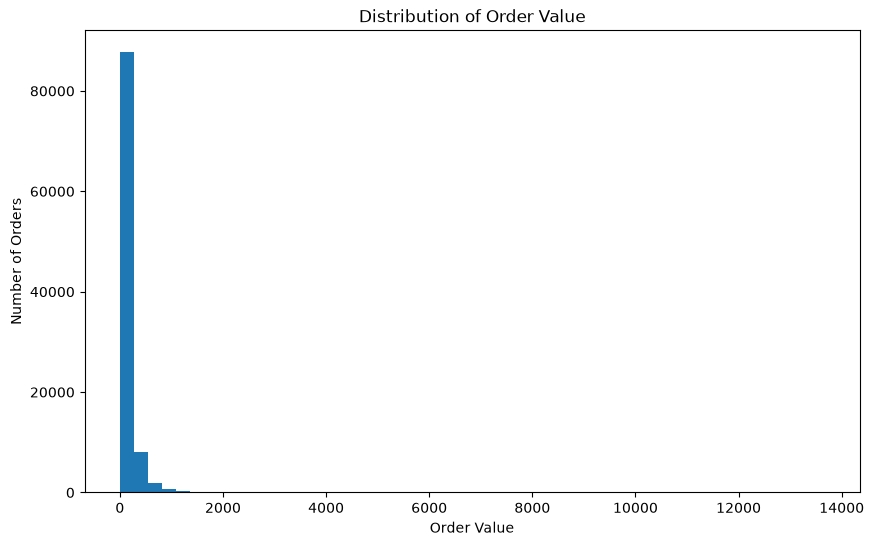

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(average_price, bins=50)

plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.title("Distribution of Order Value")

plt.show()

<b>Top categories by revenue<b>

In [ ]:
category_revenue = (
    complete_data
    .groupby("product_category_name")
    ["item_revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
category_revenue.head(10)

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      778397.77
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
Name: item_revenue, dtype: float64

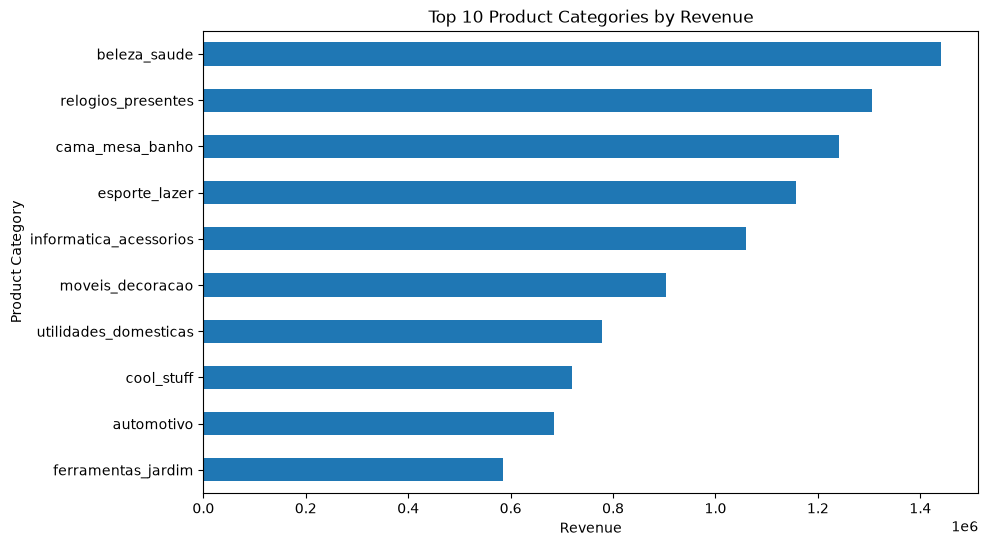

In [ ]:
category_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

plt.show()

<h4><b>Customer & Sales Behavior Analysis<b><h4>

how many orders each customer placed:

In [ ]:
customer_order = (complete_data.groupby("customer_id")["order_id"].nunique())
customer_order.describe()

count    99441.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_id, dtype: float64

In [ ]:
customer_order.value_counts().sort_index()

order_id
1    99441
Name: count, dtype: int64

calculate total spending per customer

In [ ]:
customer_revenue = (
    order_item_product_seller_payment_review
    .groupby("customer_id")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
customer_revenue.describe()

count    99441.000000
mean       159.326166
std        220.058804
min          0.000000
25%         61.050000
50%        104.560000
75%        176.000000
max      13664.080000
Name: item_revenue, dtype: float64

In [ ]:
customer_revenue.head(10)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
e0a2412720e9ea4f26c1ac985f6a7358     4809.44
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
Name: item_revenue, dtype: float64

Repeat vs one-time customers

In [ ]:
customer_type = customer_order.value_counts().sort_index()

customer_type

order_id
1    99441
Name: count, dtype: int64

In [ ]:
one_time_customers = (customer_order == 1).sum()
repeat_customers = (customer_order > 1).sum()
total_customers = customer_order.count()

one_time_customers, repeat_customers, total_customers

(np.int64(99441), np.int64(0), np.int64(99441))

Customer geography

In [ ]:
order_item_product_seller_payment_review[
    "customer_state"
].value_counts().head(10)

customer_state
SP    47820
RJ    14669
MG    13220
RS     6269
PR     5787
SC     4201
BA     3821
DF     2421
GO     2346
ES     2264
Name: count, dtype: int64

Which customer regions generate the most revenue

In [ ]:
customer_state_revenue = (
    order_item_product_seller_payment_review
    .groupby("customer_state")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_state_revenue.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: item_revenue, dtype: float64

Product performance

In [ ]:
product_sales = (
    order_item_product_seller_payment_review
    .groupby("product_id")
    .agg(
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

In [ ]:
product_sales.head(10)

,items_sold,orders,revenue
product_id,,,
bb50f2e236e5eea0100680137654686c,195,187,67606.10
d1c427060a0f73f6b889a5c7c61f2ac4,343,323,60976.03
6cdd53843498f92890544667809f1595,156,151,59093.99
99a4788cb24856965c36a24e339b6058,488,467,51071.60
d6160fb7873f184099d9bc95e30376af,35,35,50326.18
3dd2a17168ec895c781a9191c1e95ad7,274,255,48212.22
aca2eb7d00ea1a7b8ebd4e68314663af,527,431,44820.76
5f504b3a1c75b73d6151be81eb05bdc9,63,63,41725.81
25c38557cf793876c5abdd5931f922db,38,38,40311.95


Price vs quantity relationship

In [ ]:
product_analysis = (
    order_item_product_seller_payment_review
    .groupby("product_id")
    .agg(
        price=("price", "mean"),
        quantity=("order_item_id", "count"),
        revenue=("item_revenue", "sum")
    )
)

In [ ]:
product_analysis[["price", "quantity"]].corr()

,price,quantity
price,1.00000,-0.03214
quantity,-0.03214,1.00000


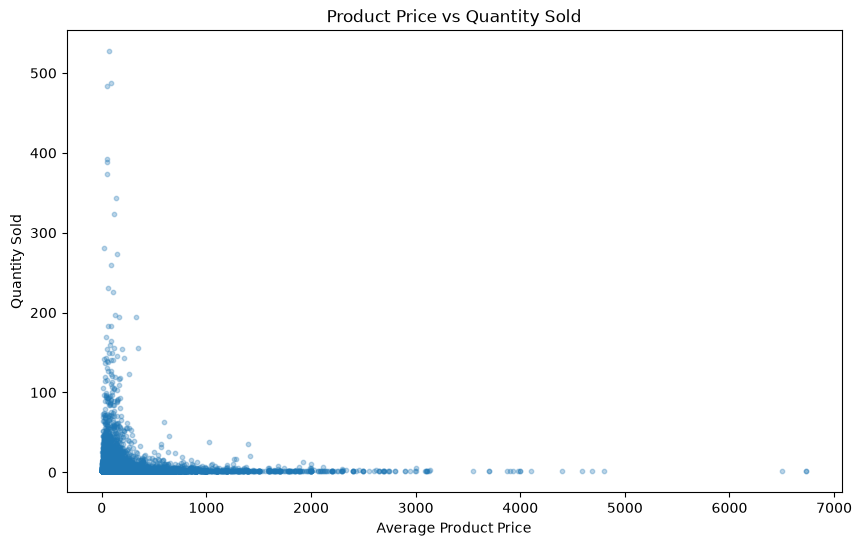

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_analysis["price"],
    product_analysis["quantity"],
    s=10,
    alpha=0.3
)

plt.xlabel("Average Product Price")
plt.ylabel("Quantity Sold")
plt.title("Product Price vs Quantity Sold")

plt.show()

<h4><b>Time-Series EDA<b><h4>

In [ ]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [ ]:
orders["order_purchase_timestamp"].min(),orders["order_purchase_timestamp"].max()

('2016-09-04 21:15:19', '2018-10-17 17:30:18')

<b>Monthly order trend<b>

In [ ]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_columns] = orders[date_columns].apply(pd.to_datetime, errors="coerce")

In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["purchase_date"] = orders["order_purchase_timestamp"].dt.date
orders["year"] = orders["order_purchase_timestamp"].dt.year
orders["month"] = orders["order_purchase_timestamp"].dt.month
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["day_of_week"] = orders["order_purchase_timestamp"].dt.day_name()
orders["hour"] = orders["order_purchase_timestamp"].dt.hour

In [ ]:
orders[
    [
        "order_purchase_timestamp",
        "purchase_date",
        "year",
        "month",
        "year_month",
        "day_of_week",
        "hour"
    ]
].head()

,order_purchase_timestamp,purchase_date,year,month,year_month,day_of_week,hour
0,2017-10-02 10:56:33,2017-10-02,2017,10,2017-10,Monday,10
1,2018-07-24 20:41:37,2018-07-24,2018,7,2018-07,Tuesday,20
2,2018-08-08 08:38:49,2018-08-08,2018,8,2018-08,Wednesday,8
3,2017-11-18 19:28:06,2017-11-18,2017,11,2017-11,Saturday,19
4,2018-02-13 21:18:39,2018-02-13,2018,2,2018-02,Tuesday,21


In [ ]:
monthly_order =( orders.groupby("month")["order_id"].nunique())
monthly_order

month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64

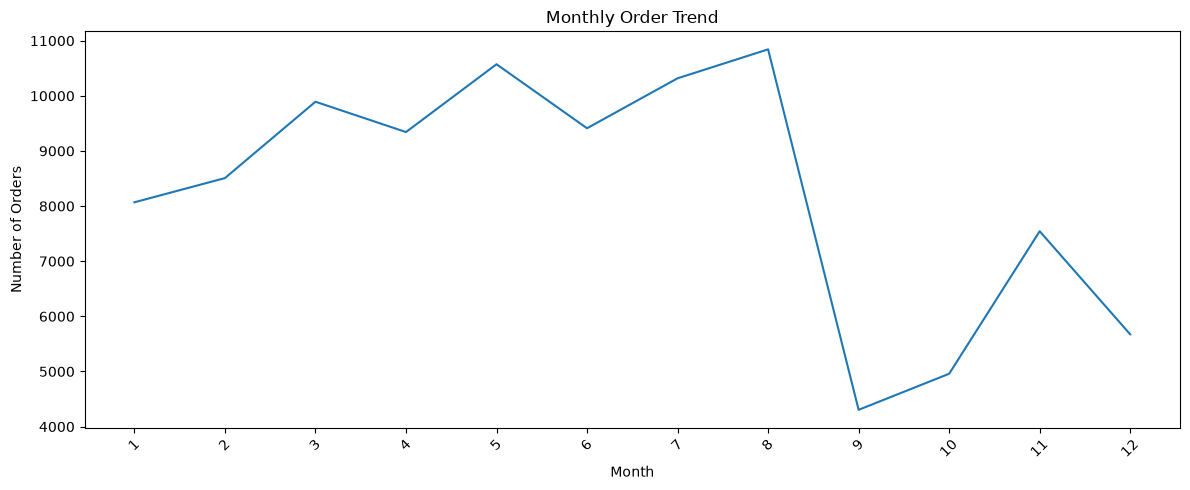

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_order.index.astype(str),
    monthly_order.values
)

plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>Monthly revenue trend<b>

In [ ]:
complete_data = (
    complete_data
    .merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left",
        validate="many_to_one"
    )
)

In [ ]:
complete_data[
    "order_purchase_timestamp"
] = pd.to_datetime(
    complete_data[
        "order_purchase_timestamp"
    ]
)

KeyError: 'order_purchase_timestamp'

In [ ]:
complete_data["year_month"] = (
    complete_data[
        "order_purchase_timestamp"
    ].dt.to_period("M")
)

In [ ]:
monthly_revenue = complete_data.groupby("year_month")["item_revenue"].sum()
monthly_revenue

year_month
2016-09        354.75
2016-10      56808.84
2016-12         19.62
2017-01     137188.49
2017-02     286280.62
2017-03     432048.59
2017-04     412422.24
2017-05     586190.95
2017-06     502963.04
2017-07     584971.62
2017-08     668204.60
2017-09     720398.91
2017-10     769312.37
2017-11    1179143.77
2017-12     863547.23
2018-01    1107301.89
2018-02     986908.96
2018-03    1155126.82
2018-04    1159698.04
2018-05    1149781.82
2018-06    1022677.11
2018-07    1058728.03
2018-08    1003308.47
2018-09        166.46
2018-10          0.00
Freq: M, Name: item_revenue, dtype: float64

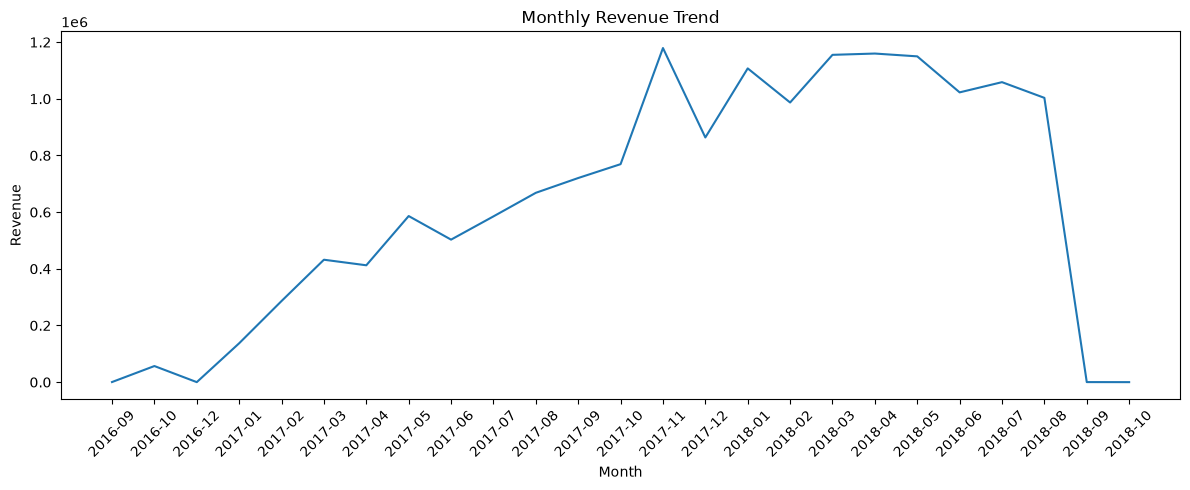

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>Monthly Average Order Value<b>

In [ ]:
monthly_avg_revenue = (monthly_revenue / monthly_order)
monthly_avg_revenue

year_month
2016-09   NaN
2016-10   NaN
2016-12   NaN
2017-01   NaN
2017-02   NaN
2017-03   NaN
2017-04   NaN
2017-05   NaN
2017-06   NaN
2017-07   NaN
2017-08   NaN
2017-09   NaN
2017-10   NaN
2017-11   NaN
2017-12   NaN
2018-01   NaN
2018-02   NaN
2018-03   NaN
2018-04   NaN
2018-05   NaN
2018-06   NaN
2018-07   NaN
2018-08   NaN
2018-09   NaN
2018-10   NaN
1         NaN
2         NaN
3         NaN
4         NaN
5         NaN
6         NaN
7         NaN
8         NaN
9         NaN
10        NaN
11        NaN
12        NaN
dtype: float64

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg_revenue.index.astype(str),
    monthly_avg_revenue.values
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'monthly_avg_revenue' is not defined

<Figure size 1200x500 with 0 Axes>

<b>Monthly growth %<b>

In [ ]:
monthly_revenue_growth =( monthly_revenue.pct_change() * 100)
monthly_revenue_growth

year_month
2016-09              NaN
2016-10     15913.767442
2016-12       -99.965463
2017-01    699127.777778
2017-02       108.676850
2017-03        50.917862
2017-04        -4.542626
2017-05        42.133690
2017-06       -14.198089
2017-07        16.305091
2017-08        14.228550
2017-09         7.811127
2017-10         6.789774
2017-11        53.272431
2017-12       -26.764891
2018-01        28.227137
2018-02       -10.872638
2018-03        17.044922
2018-04         0.395733
2018-05        -0.855069
2018-06       -11.054681
2018-07         3.525152
2018-08        -5.234542
2018-09       -99.983409
2018-10      -100.000000
Freq: M, Name: item_revenue, dtype: float64

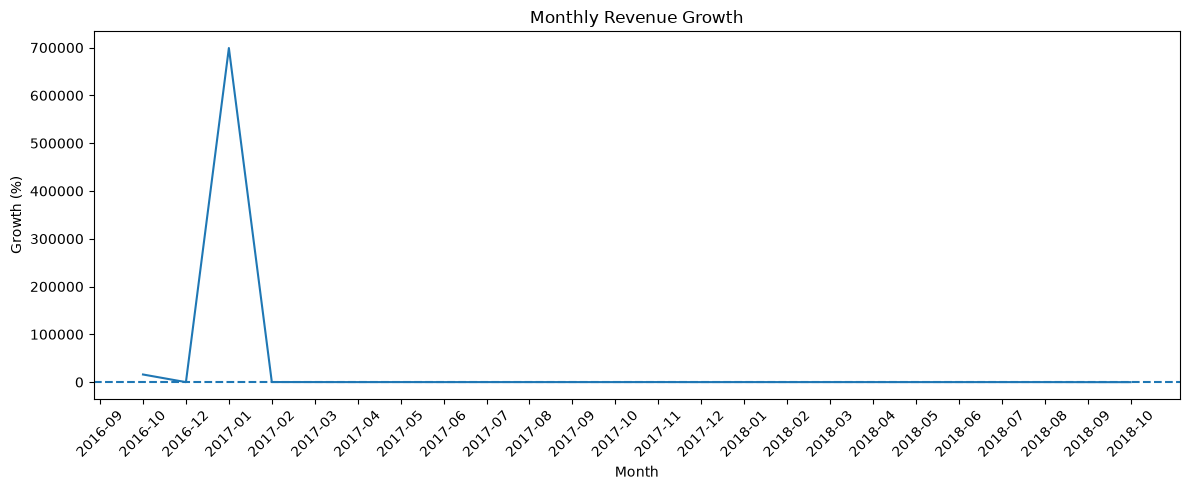

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue_growth.index.astype(str),
    monthly_revenue_growth.values
)

plt.axhline(0, linestyle="--")

plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.title("Monthly Revenue Growth")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>Monthly Order Growth %<b>

In [ ]:
monthly_order_growth = monthly_order.pct_change() * 100
monthly_order_growth

month
1           NaN
2      5.440575
3     16.278796
4     -5.559487
5     13.164936
6    -10.980800
7      9.626009
8      5.088195
9    -60.296966
10    15.191638
11    52.127445
12   -24.787911
Name: order_id, dtype: float64

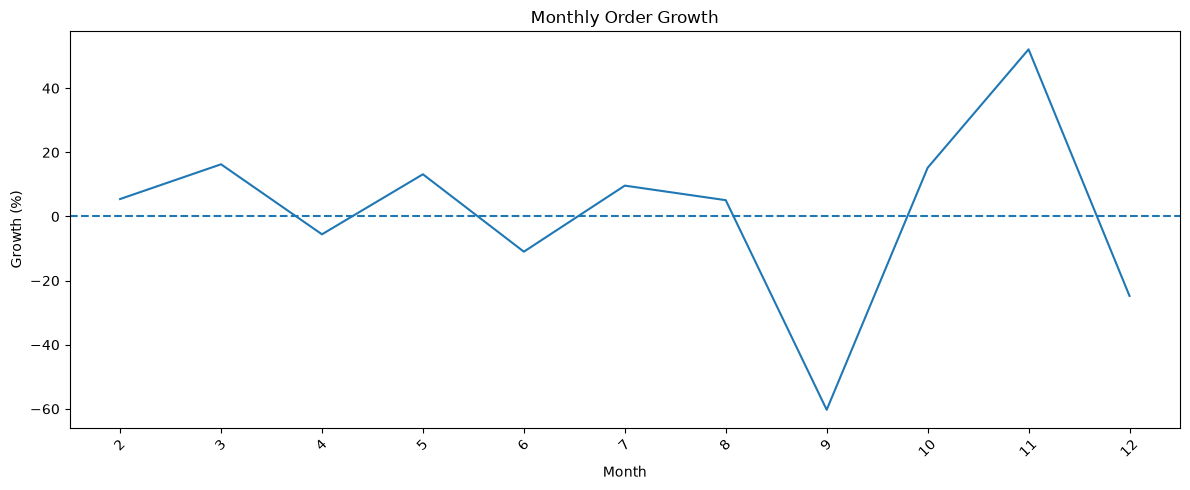

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_order_growth.index.astype(str),
    monthly_order_growth.values
)

plt.axhline(0, linestyle="--")

plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.title("Monthly Order Growth")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>Yearly comparison<b>

In [ ]:
yearly_orders = (
    orders
    .groupby("year")["order_id"]
    .nunique()
)

yearly_orders

year
2016      329
2017    45101
2018    54011
Name: order_id, dtype: int64

In [ ]:
yearly_revenue = (
    complete_data
    .groupby(
        complete_data[
            "order_purchase_timestamp"
        ].dt.year
    )["item_revenue"]
    .sum()
)

yearly_revenue

order_purchase_timestamp
2016      57183.21
2017    7142672.43
2018    8643697.60
Name: item_revenue, dtype: float64

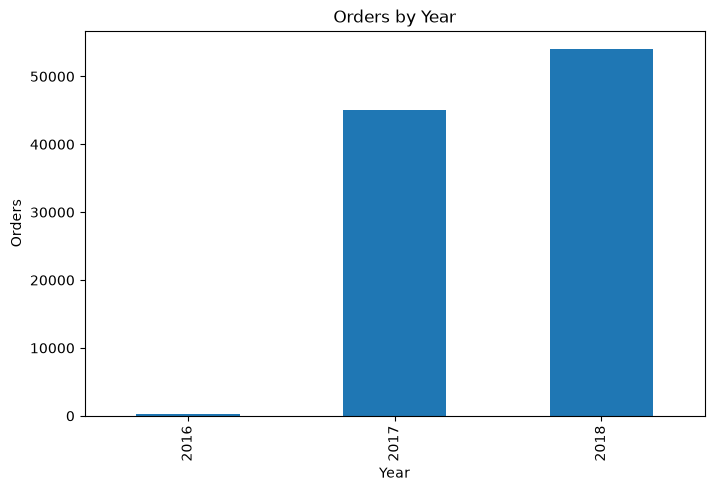

In [ ]:
yearly_orders.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Year")
plt.ylabel("Orders")
plt.title("Orders by Year")

plt.show()

<b>Day-of-week analysis<b>

In [ ]:
day_orders = (
    orders
    .groupby("day_of_week")["order_id"]
    .nunique()
)

In [ ]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_orders = day_orders.reindex(day_order)
day_orders

day_of_week
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: order_id, dtype: int64

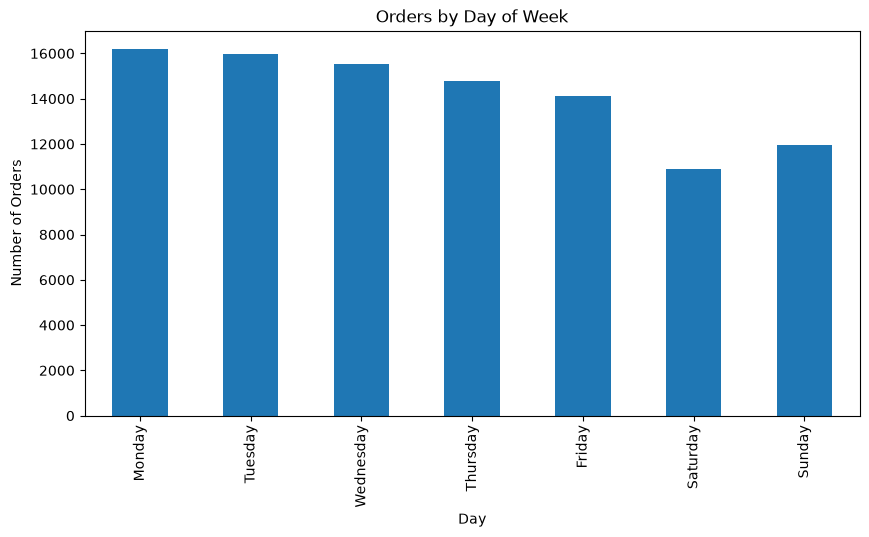

In [ ]:
day_orders.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of Week")

plt.show()

<h4><b>Delivery Performance EDA<b><h4>

delivery-time distribution

In [ ]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,year,month,year_month,day_of_week,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017,10,2017-10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018,7,2018-07,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018,8,2018-08,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017,11,2017-11,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018,2,2018-02,Tuesday,21


In [ ]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [ ]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

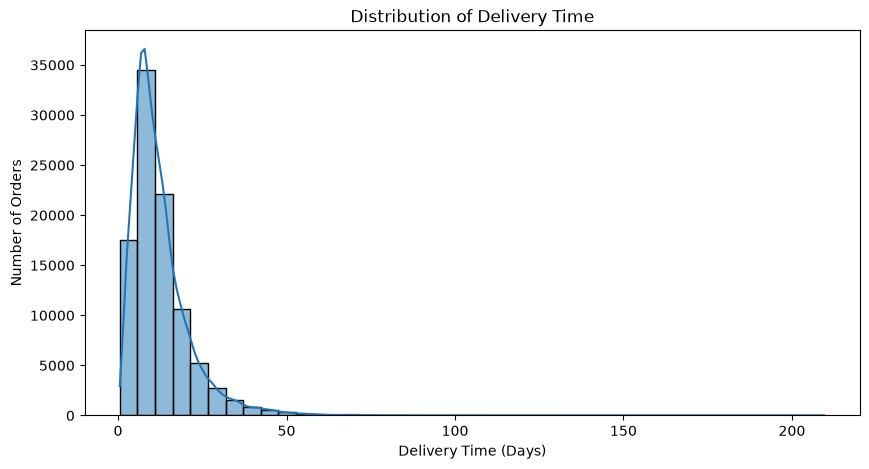

In [ ]:

import  seaborn as sns
plt.figure(figsize=(10,5))

sns.histplot(
    orders["delivery_days"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

Estimated vs actual delivery

In [ ]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [ ]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

In [ ]:
orders["delivery_status"] = np.where(
    orders["delivery_delay_days"].isna(),
    "Not Delivered",
    np.where(
        orders["delivery_delay_days"] > 0,
        "Late",
        np.where(
            orders["delivery_delay_days"] < 0,
            "Early",
            "On Time"
        )
    )
)

In [ ]:
orders["delivery_status"].value_counts()

delivery_status
Early            88649
Late              7827
Not Delivered     2965
Name: count, dtype: int64

In [ ]:
orders["delivery_status"].value_counts(normalize=True) * 100

delivery_status
Early            89.147334
Late              7.870999
Not Delivered     2.981668
Name: proportion, dtype: float64

<b>Calculate Late Delivery Rate<b>

In [ ]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,year,month,year_month,day_of_week,hour,delivery_days,delivery_delay_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017,10,2017-10,Monday,10,8.436574,-7.107488,Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018,7,2018-07,Tuesday,20,13.782037,-5.355729,Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018,8,2018-08,Wednesday,8,9.394213,-17.245498,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017,11,2017-11,Saturday,19,13.208750,-12.980069,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018,2,2018-02,Tuesday,21,2.873877,-9.238171,Early


In [ ]:
delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

In [ ]:
late_rate = (
    delivered_orders["delivery_delay_days"] > 0
).mean() * 100

late_rate

np.float64(8.112898544715783)

In [ ]:
delivery_performance = (
    delivered_orders["delivery_status"]
    .value_counts(normalize=True) * 100
)

delivery_performance

delivery_status
Early    91.887101
Late      8.112899
Name: proportion, dtype: float64

<b>Delivery performance by customer state<b>

In [ ]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,year,month,year_month,day_of_week,hour,delivery_delay_days,delivery_status,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017,10,2017-10,Monday,10,-7.107488,Early,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018,7,2018-07,Tuesday,20,-5.355729,Early,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018,8,2018-08,Wednesday,8,-17.245498,Early,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017,11,2017-11,Saturday,19,-12.980069,Early,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018,2,2018-02,Tuesday,21,-9.238171,Early,2.873877


In [ ]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   purchase_date                  99441 non-null  object        
 9   year                           99441 non-null  int32         
 10  month                          99441 non-null  int32         
 11  year_month                

In [ ]:
orders["delivery_status"] = np.where(
    orders["delivery_delay_days"].isna(),
    "Not Delivered",
    np.where(
        orders["delivery_delay_days"] > 0,
        "Late",
        np.where(
            orders["delivery_delay_days"] < 0,
            "Early",
            "On Time"
        )
    )
)

In [ ]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [ ]:
order_customer.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
order_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
 8   customer_unique_id             99441 non-null  str  
 9   customer_zip_code_prefix       99441 non-null  int64
 10  customer_city                  99441 non-null  str  
 11  customer_state                 99441 non-null  str  
dtypes: int64(1), str(11)
memory usage: 9.1 MB


In [ ]:
order_customer_merge = order_customer.merge(
    orders[
        [
            "order_id",
            "delivery_delay_days",
            "delivery_status",
            "delivery_days"
        ]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [ ]:
order_customer_merge.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_delay_days,delivery_status,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-7.107488,Early,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-5.355729,Early,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-17.245498,Early,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-12.980069,Early,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-9.238171,Early,2.873877


In [ ]:
order_customer_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  str    
 1   customer_id                    99441 non-null  str    
 2   order_status                   99441 non-null  str    
 3   order_purchase_timestamp       99441 non-null  str    
 4   order_approved_at              99281 non-null  str    
 5   order_delivered_carrier_date   97658 non-null  str    
 6   order_delivered_customer_date  96476 non-null  str    
 7   order_estimated_delivery_date  99441 non-null  str    
 8   customer_unique_id             99441 non-null  str    
 9   customer_zip_code_prefix       99441 non-null  int64  
 10  customer_city                  99441 non-null  str    
 11  customer_state                 99441 non-null  str    
 12  delivery_delay_days            96476 non-null  float64
 1

In [ ]:
state_delivery = (
    order_customer_merge
    .groupby("customer_state")
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_rate=("delivery_delay_days",
                   lambda x: (x > 0).mean() * 100),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
state_delivery.sort_values(
    "late_rate",
    ascending=False
).head(10)

,customer_state,avg_delivery_days,median_delivery_days,late_rate,orders
1,AL,24.543855,22.332917,23.002421,413
9,MA,21.572976,19.190602,18.875502,747
16,PI,19.457098,16.292269,15.353535,495
5,CE,21.266579,18.209201,14.670659,1336
24,SE,21.519788,18.014306,14.571429,350
4,BA,19.335466,16.913964,13.520710,3380
18,RJ,15.310053,12.041308,12.947401,12852
26,TO,17.658063,15.865885,12.500000,280
7,ES,15.789307,13.636956,12.001968,2033
13,PA,23.772917,21.078391,12.000000,975


<b>Delivery time vs Review Score<b>

In [ ]:
review_summary.head(5
)

,order_id,review_count,review_score_avg,review_score_min,review_score_max,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,5.0,5,5,2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,4.0,4,4,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,5.0,5,5,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,4.0,4,4,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,5.0,5,5,2017-03-02,2017-03-03 10:54:59


In [ ]:
order_delivery_review = orders.merge(
    review_summary[
        ["order_id", "review_score_avg"]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [ ]:
delivery_review = (
    order_delivery_review[
        order_delivery_review["review_score_avg"].notna()
    ]
    .groupby("review_score_avg")
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

delivery_review

,review_score_avg,avg_delivery_days,avg_delay_days,orders
0,1.000000,21.339995,-3.336156,11316
1,1.500000,17.528027,-5.342746,8
2,2.000000,16.663602,-7.938540,3125
3,2.500000,18.670304,-6.819354,34
4,3.000000,14.246112,-10.084415,8136
5,3.333333,22.033148,-13.091065,1
6,3.500000,13.282356,-13.220016,25
7,4.000000,12.306680,-11.682696,19018
8,4.333333,3.765359,-10.287153,1
9,4.500000,12.803099,-12.358327,54


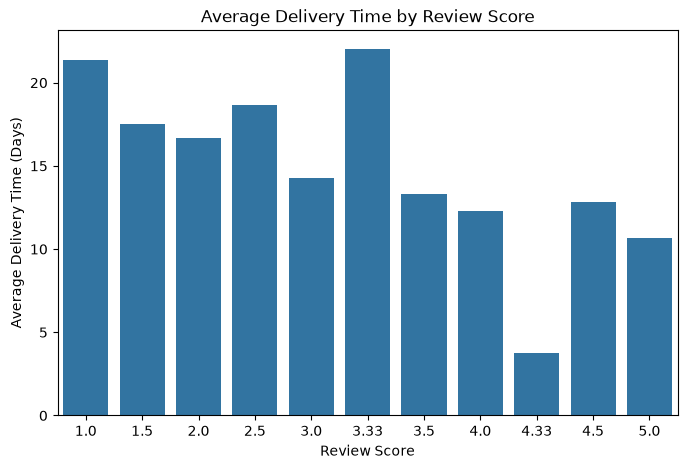

In [ ]:
delivery_review["review_score_avg"] = delivery_review["review_score_avg"].round(2)
plt.figure(figsize=(8,5))

sns.barplot(
    data=delivery_review,
    x="review_score_avg",
    y="avg_delivery_days"
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

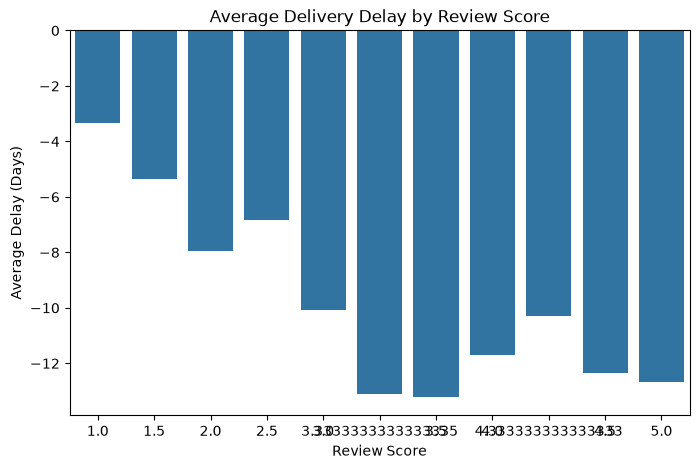

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=delivery_review,
    x="review_score_avg",
    y="avg_delay_days"
)

plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delay (Days)")

plt.show()

<b>Delivery performance over time<b>

In [ ]:
monthly_delivery = (
    delivered_orders
    .groupby("year_month")
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("delivery_delay_days",
                   lambda x: (x > 0).mean() * 100),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
monthly_delivery["year_month"] = (
    monthly_delivery["year_month"].astype(str)
)

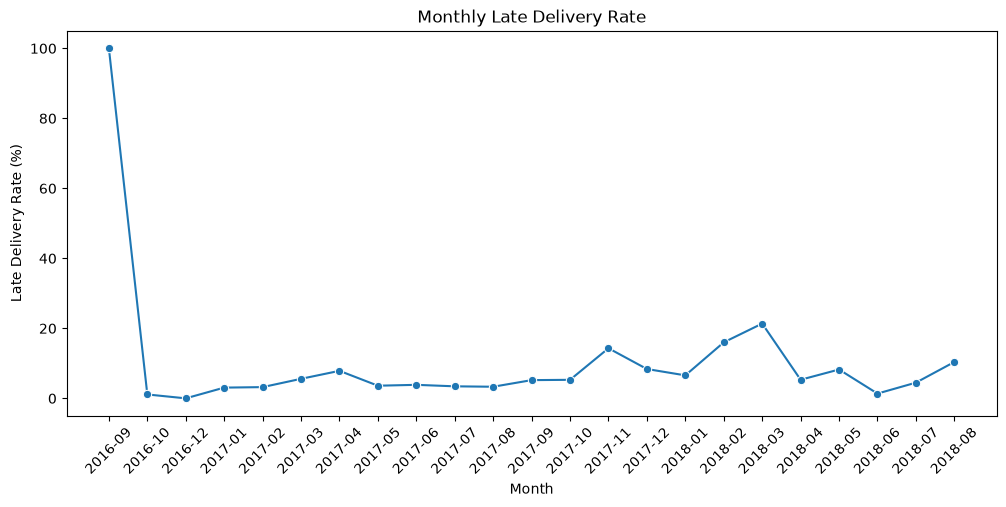

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_delivery,
    x="year_month",
    y="late_rate",
    marker="o"
)

plt.title("Monthly Late Delivery Rate")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(rotation=45)
plt.show()

<h4><b>Customer Satisfaction / Review EDA<b><h4>

In [ ]:
review_percentage = (
    order_reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

review_percentage

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

Calculate satisfaction metrics

In [ ]:
total_review = order_reviews["review_score"].notna().sum()

positive_review =( order_reviews["review_score"] >= 4 ).sum()
neutral_review =( order_reviews["review_score"]  == 3 ).sum()
negative_review =( order_reviews["review_score"] <= 2 ).sum()

print("total_review ==",total_review)
print("positive_review ==",positive_review)
print("neutral_review ==",neutral_review)
print("negative_review ==",negative_review)

print("Positive %:", positive_review / total_review * 100)
print("Neutral %:", neutral_review / total_review * 100)
print("Negative %:", negative_review / total_review * 100)

total_review == 99224
positive_review == 76470
neutral_review == 8179
negative_review == 14575
Positive %: 77.06804805289042
Neutral %: 8.24296541159397
Negative %: 14.688986535515603


Review Score by Product Category

In [ ]:
complete_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  str           
 1   customer_id                    113425 non-null  str           
 2   order_status                   113425 non-null  str           
 3   order_purchase_timestamp_x     113425 non-null  str           
 4   order_approved_at              113264 non-null  str           
 5   order_delivered_carrier_date   111457 non-null  str           
 6   order_delivered_customer_date  110196 non-null  str           
 7   order_estimated_delivery_date  113425 non-null  str           
 8   customer_unique_id             113425 non-null  str           
 9   customer_zip_code_prefix       113425 non-null  int64         
 10  customer_city                  113425 non-null  str           
 11  customer_st

category with high average score

In [ ]:
category_review = (complete_data.groupby("product_category_name")
                   .agg(review_score_avg =("review_score_avg" ,"mean"),
                       orders=("order_id","nunique")
                         ).reset_index()
                         )
category_review.sort_values("review_score_avg",ascending=False).head(10)

,product_category_name,review_score_avg,orders
17,cds_dvds_musicais,4.642857,12
37,fashion_roupa_infanto_juvenil,4.500000,8
48,livros_interesse_geral,4.446266,512
22,construcao_ferramentas_ferramentas,4.444444,97
41,flores,4.419355,29
47,livros_importados,4.400000,53
49,livros_tecnicos,4.363636,260
50,malas_acessorios,4.315257,1034
2,alimentos_bebidas,4.312274,227
64,portateis_casa_forno_e_cafe,4.302632,75


category with low avg score

In [ ]:
category_review.sort_values(
    "review_score_avg",
    ascending=True
).head(10)

,product_category_name,review_score_avg,orders
67,seguros_e_servicos,2.500000,2
42,fraldas_higiene,3.256410,27
65,portateis_cozinha_e_preparadores_de_alimentos,3.266667,14
60,pc_gamer,3.333333,8
55,moveis_escritorio,3.488968,1273
15,casa_conforto_2,3.629630,24
38,fashion_roupa_masculina,3.641221,112
71,telefonia_fixa,3.681992,217
5,artigos_de_festas,3.767442,39
36,fashion_roupa_feminina,3.781250,39


category avg score for order more than 100

In [ ]:
category_review_filtered = category_review[
    category_review["orders"] >= 100
]
category_review_filtered.head(10
                              )

,product_category_name,review_score_avg,orders
0,agro_industria_e_comercio,4.000000,182
1,alimentos,4.218182,450
2,alimentos_bebidas,4.312274,227
3,artes,3.937198,202
6,artigos_de_natal,4.020548,128
7,audio,3.831944,350
8,automotivo,4.064885,3897
9,bebes,4.010691,2885
10,bebidas,4.037534,297
11,beleza_saude,4.141827,8836


Review Score by Customer State 

In [ ]:
state_review = (
    complete_data
    .groupby("customer_state")
    .agg(
        avg_review_score=("review_score_avg", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
state_review = state_review[
    state_review["orders"] >= 100
]
state_review.head(10)

,customer_state,avg_review_score,orders
1,AL,3.722348,413
2,AM,4.079268,148
4,BA,3.802230,3380
5,CE,3.796748,1336
6,DF,3.995004,2140
7,ES,3.979167,2033
8,GO,3.982027,2020
9,MA,3.690909,747
10,MG,4.069713,11635
11,MS,4.021264,715


In [ ]:
state_review.sort_values(
    "avg_review_score",
    ascending=False
).head(10)

,customer_state,avg_review_score,orders
25,SP,4.109301,41746
26,TO,4.104762,280
17,PR,4.089078,5045
2,AM,4.079268,148
19,RN,4.073055,485
10,MG,4.069713,11635
22,RS,4.042441,5466
11,MS,4.021264,715
6,DF,3.995004,2140
23,SC,3.990398,3637


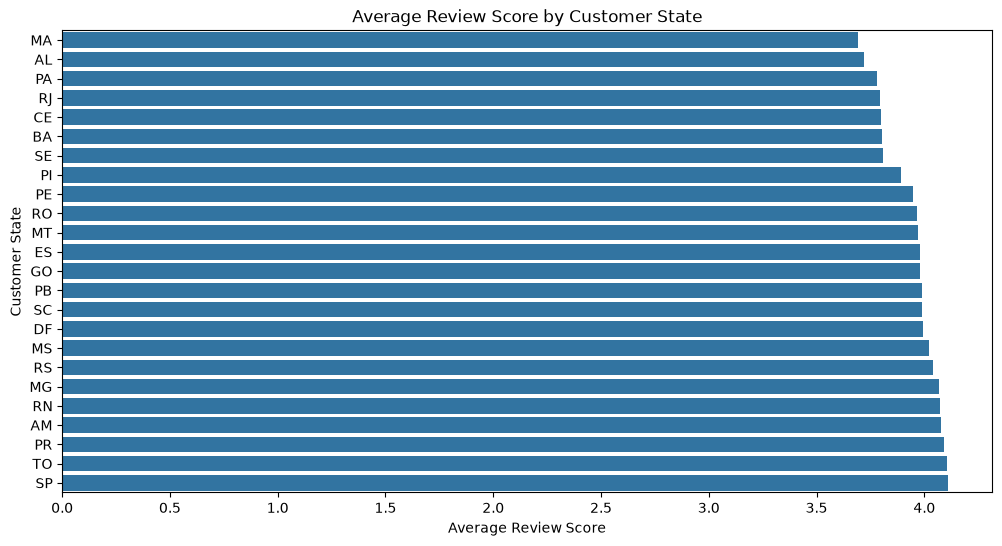

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_review.sort_values("avg_review_score"),
    x="avg_review_score",
    y="customer_state"
)

plt.title("Average Review Score by Customer State")
plt.xlabel("Average Review Score")
plt.ylabel("Customer State")

plt.show()

<h4><b>Product & Seller Deep Analysis<b><h4>

<b>Category Revenue vs Quantity<b>

In [ ]:
category_performance = (
    complete_data
    .groupby("product_category_name")
    .agg(
        quantity=("order_id", "count"),
        revenue=("item_revenue", "sum"),
        avg_price=("price", "mean"),
        avg_review_score=("review_score_avg", "mean")
    )
    .reset_index()
)

Sort by revenue

In [ ]:
category_performance.sort_values(
    "revenue",
    ascending=False
).head(10)

,product_category_name,quantity,revenue,avg_price,avg_review_score
11,beleza_saude,9670,1441248.07,130.163531,4.141827
66,relogios_presentes,5991,1305541.61,201.135984,4.018855
13,cama_mesa_banho,11115,1241681.72,93.296327,3.898334
32,esporte_lazer,8641,1156656.48,114.344285,4.107039
44,informatica_acessorios,7827,1059272.40,116.513903,3.932601
54,moveis_decoracao,8334,902511.79,87.564494,3.907333
72,utilidades_domesticas,6964,778397.77,90.788148,4.054785
26,cool_stuff,3796,719329.95,167.357969,4.146598
8,automotivo,4235,685384.32,139.957523,4.064885
40,ferramentas_jardim,4347,584219.21,111.630196,4.045539


Sort by quantity

In [ ]:
category_performance.sort_values(
    "quantity",
    ascending=False
).head(10)

,product_category_name,quantity,revenue,avg_price,avg_review_score
13,cama_mesa_banho,11115,1241681.72,93.296327,3.898334
11,beleza_saude,9670,1441248.07,130.163531,4.141827
32,esporte_lazer,8641,1156656.48,114.344285,4.107039
54,moveis_decoracao,8334,902511.79,87.564494,3.907333
44,informatica_acessorios,7827,1059272.40,116.513903,3.932601
72,utilidades_domesticas,6964,778397.77,90.788148,4.054785
66,relogios_presentes,5991,1305541.61,201.135984,4.018855
70,telefonia,4545,394883.32,71.213978,3.945922
40,ferramentas_jardim,4347,584219.21,111.630196,4.045539
8,automotivo,4235,685384.32,139.957523,4.064885


Visualization  Revenue

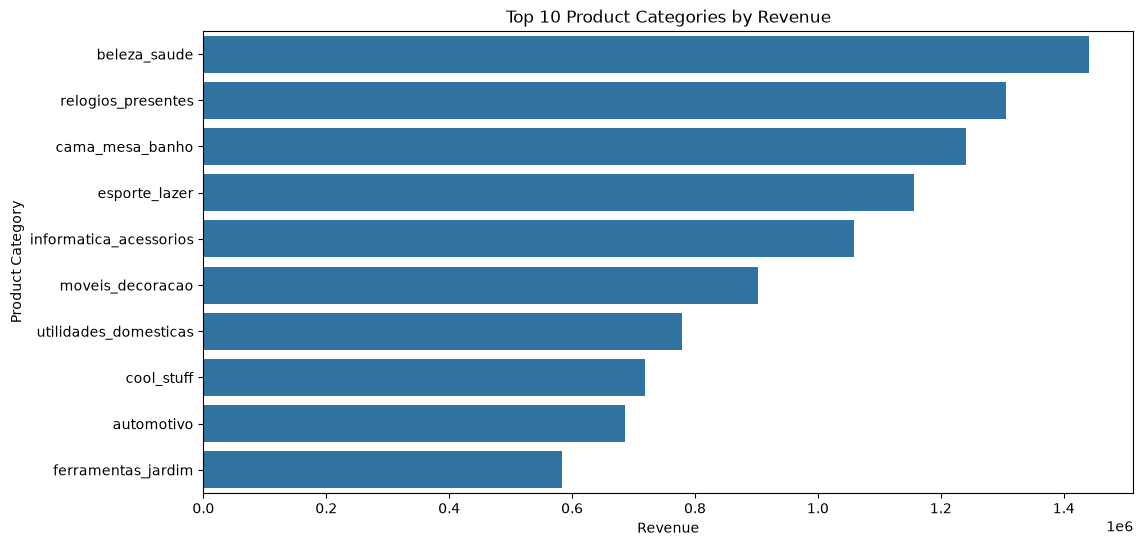

In [ ]:
import seaborn as sns
top_categories = (
    category_performance
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category_name"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.show()

Visualization Quantity

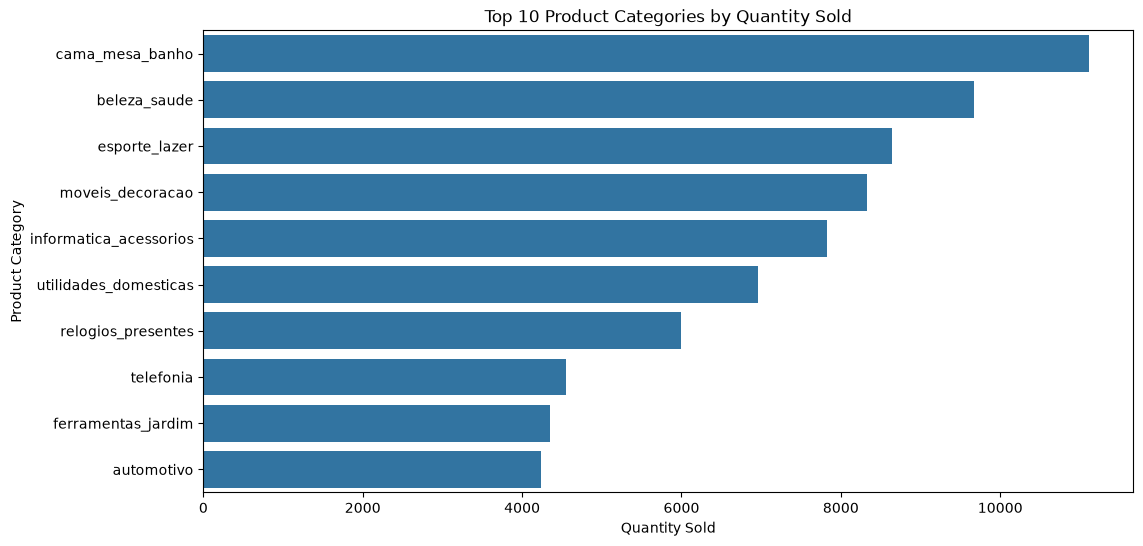

In [ ]:
top_quantity = (
    category_performance
    .sort_values("quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_quantity,
    x="quantity",
    y="product_category_name"
)

plt.title("Top 10 Product Categories by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.show()

<b>Freight Cost vs Product Price<b>

In [ ]:
complete_data["freight_ration"] = np.where(
    complete_data["price"]>0,
    complete_data["freight_value"]/complete_data["price"],
    np.nan
)

In [ ]:
freight_analysis = (
    complete_data
    .groupby("product_category_name")
    .agg(
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_freight_ratio=("freight_ration", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
    
)

Filter small categories

In [ ]:
freight_analysis = freight_analysis[
    freight_analysis["orders"] >= 100
].head(10)
freight_analysis

,product_category_name,avg_price,avg_freight,avg_freight_ratio,orders
0,agro_industria_e_comercio,342.124858,27.564151,0.274248,182
1,alimentos,57.634137,14.256922,0.348089,450
2,alimentos_bebidas,54.602446,16.215791,0.498291,227
3,artes,115.802105,19.354880,0.299337,202
6,artigos_de_natal,57.521699,21.106536,0.675660,128
7,audio,139.254121,15.688022,0.331233,350
8,automotivo,139.957523,21.880569,0.331672,3897
9,bebes,134.344173,22.301178,0.293226,2885
10,bebidas,59.178628,15.148417,0.427505,297
11,beleza_saude,130.163531,18.879703,0.302081,8836


Top freight ratio

In [ ]:
freight_analysis.sort_values(
    "avg_freight_ratio",
    ascending=False
).head(10)

,product_category_name,avg_price,avg_freight,avg_freight_ratio,orders
6,artigos_de_natal,57.521699,21.106536,0.675660,128
2,alimentos_bebidas,54.602446,16.215791,0.498291,227
10,bebidas,59.178628,15.148417,0.427505,297
1,alimentos,57.634137,14.256922,0.348089,450
8,automotivo,139.957523,21.880569,0.331672,3897
7,audio,139.254121,15.688022,0.331233,350
11,beleza_saude,130.163531,18.879703,0.302081,8836
3,artes,115.802105,19.354880,0.299337,202
9,bebes,134.344173,22.301178,0.293226,2885
0,agro_industria_e_comercio,342.124858,27.564151,0.274248,182


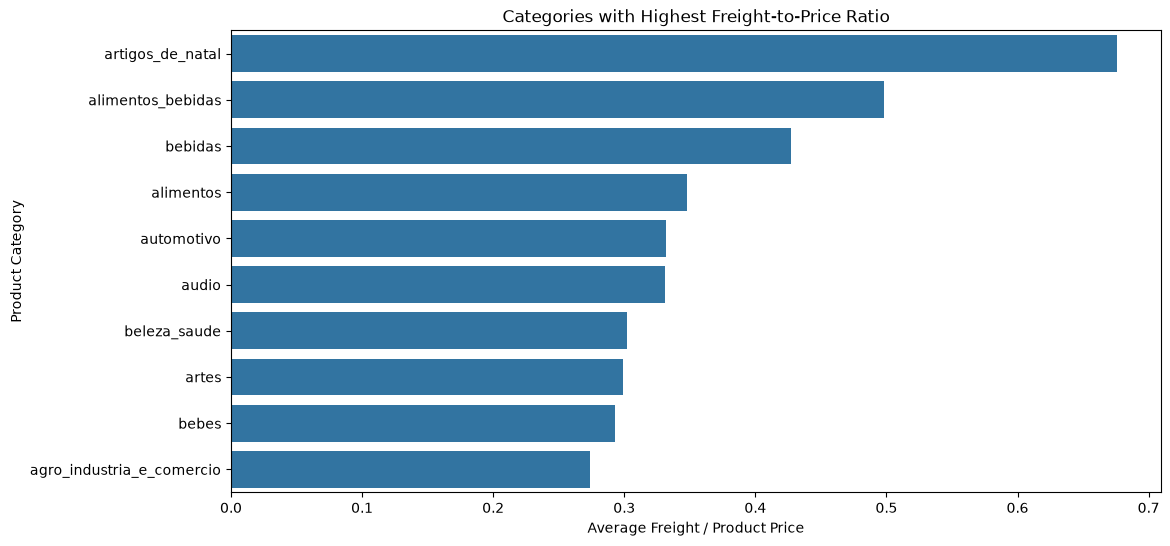

In [ ]:
top_freight = (
    freight_analysis
    .sort_values("avg_freight_ratio", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_freight,
    x="avg_freight_ratio",
    y="product_category_name"
)

plt.title("Categories with Highest Freight-to-Price Ratio")
plt.xlabel("Average Freight / Product Price")
plt.ylabel("Product Category")

plt.show()

<b>Which categories sell well but have poor customer satisfaction?<b>

In [ ]:
category_performance.sort_values(
    "revenue",
    ascending=False
).head(15)

,product_category_name,quantity,revenue,avg_price,avg_review_score
11,beleza_saude,9670,1441248.07,130.163531,4.141827
66,relogios_presentes,5991,1305541.61,201.135984,4.018855
13,cama_mesa_banho,11115,1241681.72,93.296327,3.898334
32,esporte_lazer,8641,1156656.48,114.344285,4.107039
44,informatica_acessorios,7827,1059272.40,116.513903,3.932601
54,moveis_decoracao,8334,902511.79,87.564494,3.907333
72,utilidades_domesticas,6964,778397.77,90.788148,4.054785
26,cool_stuff,3796,719329.95,167.357969,4.146598
8,automotivo,4235,685384.32,139.957523,4.064885
40,ferramentas_jardim,4347,584219.21,111.630196,4.045539


In [ ]:
category_performance[
    category_performance["revenue"] >=
    category_performance["revenue"].quantile(0.75)
].sort_values(
    "avg_review_score"
)

,product_category_name,quantity,revenue,avg_price,avg_review_score
55,moveis_escritorio,1691,342532.65,162.011059,3.488968
13,cama_mesa_banho,11115,1241681.72,93.296327,3.898334
54,moveis_decoracao,8334,902511.79,87.564494,3.907333
44,informatica_acessorios,7827,1059272.40,116.513903,3.932601
70,telefonia,4545,394883.32,71.213978,3.945922
9,bebes,3065,480118.00,134.344173,4.010691
66,relogios_presentes,5991,1305541.61,201.135984,4.018855
40,ferramentas_jardim,4347,584219.21,111.630196,4.045539
72,utilidades_domesticas,6964,778397.77,90.788148,4.054785
8,automotivo,4235,685384.32,139.957523,4.064885


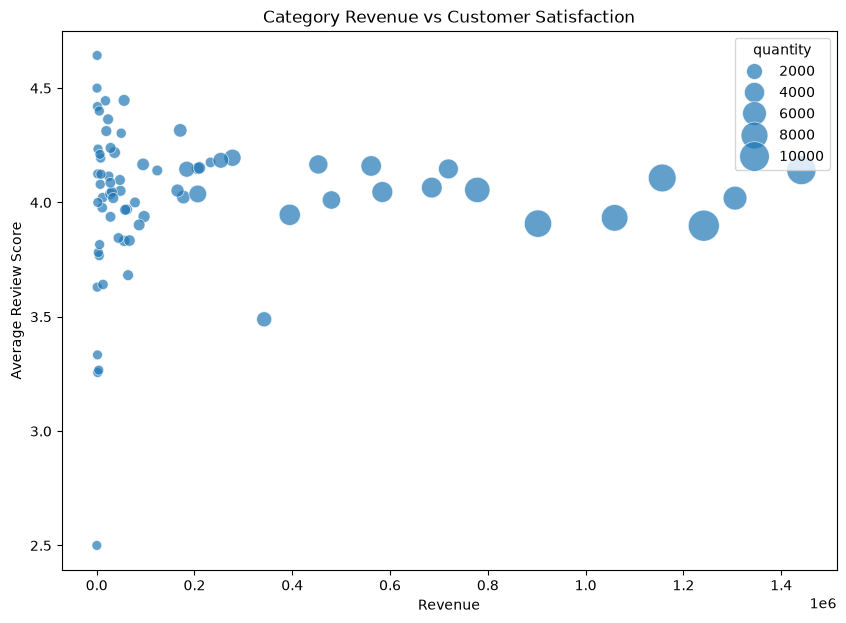

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=category_performance,
    x="revenue",
    y="avg_review_score",
    size="quantity",
    sizes=(50,500),
    alpha=0.7
)

plt.title("Category Revenue vs Customer Satisfaction")
plt.xlabel("Revenue")
plt.ylabel("Average Review Score")

plt.show()

<b>Seller Revenue Ranking<b>

In [ ]:
seller_performance = (
    complete_data
    .groupby("seller_id")
    .agg(
        revenue=("item_revenue", "sum"),
        orders=("order_id", "nunique"),
        quantity=("order_id", "count"),
        avg_price=("price", "mean"),
        avg_review_score=("review_score_avg", "mean")
    )
    .reset_index()
)

In [ ]:
seller_performance.sort_values(
    "revenue",
    ascending=False
).head(10)

,seller_id,revenue,orders,quantity,avg_price,avg_review_score
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132,1156,198.505735,4.122822
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44,982,1364,137.774113,3.341445
1013,53243585a1d6dc2643021fd1853d8905,235856.68,358,410,543.356220,4.075980
881,4a3ca9315b744ce9f8e9374361493884,235539.96,1806,1987,100.892260,3.803262
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585,586,331.129744,4.340206
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1314,1551,103.311779,4.063754
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05,336,340,518.917265,4.206490
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,915,1428,97.316912,3.853107
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38,1160,1171,121.046567,4.234509
1824,955fee9216a65b617aa5c0531780ce60,160602.68,1287,1499,90.174583,4.050437


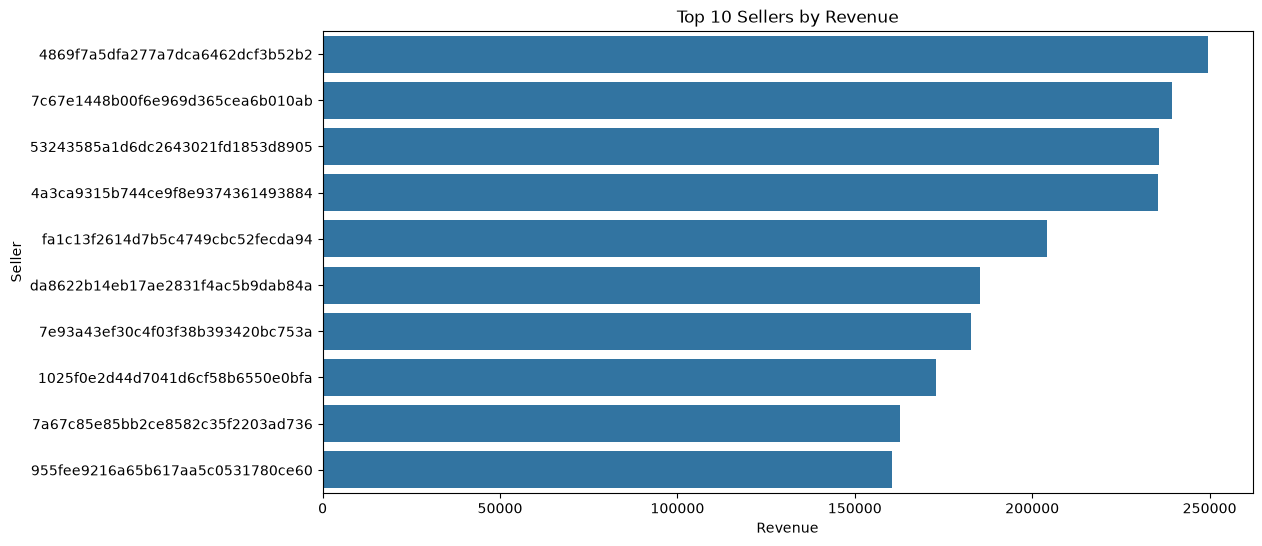

In [ ]:
top_sellers = (
    seller_performance
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sellers,
    x="revenue",
    y="seller_id"
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller")

plt.show()

<b>Seller Satisfaction<b>

In [ ]:
seller_satisfaction = (
    complete_data
    .groupby("seller_id")
    .agg(
        avg_review_score=("review_score_avg", "mean"),
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum")
    )
    .reset_index()
)

In [ ]:
seller_satisfaction = seller_satisfaction[
    seller_satisfaction["orders"] >= 50
]

In [ ]:
seller_satisfaction.sort_values(
    "avg_review_score"
).head(10)

,seller_id,avg_review_score,orders,revenue
333,1ca7077d890b907f89be8c954a02686a,2.198529,115,15001.43
554,2eb70248d66e0e3ef83659f71b244378,2.713942,202,45860.10
1032,54965bbe3e4f07ae045b90b0b8541f52,2.938272,78,13164.84
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,2.952830,98,10574.25
1846,972d0f9cf61b499a4812cf0bfa3ad3c4,2.964286,83,10240.59
1178,602044f2c16190c2c6e45eb35c2e21cb,2.964286,50,4677.44
1747,8e6d7754bc7e0f22c96d255ebda59eba,2.973077,85,16212.51
492,2a1348e9addc1af5aaa619b1a3679d6b,3.000000,52,3631.40
2257,bbad7e518d7af88a0897397ffdca1979,3.035714,69,5800.42
1626,8444e55c1f13cd5c179851e5ca5ebd00,3.073394,99,24951.27


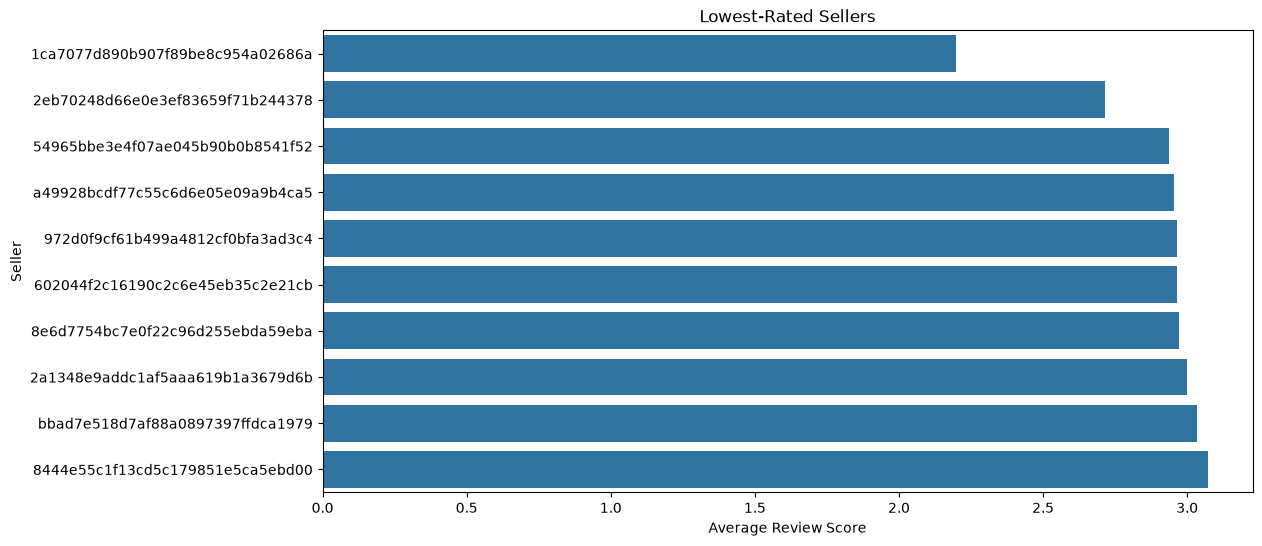

In [ ]:
worst_sellers = (
    seller_satisfaction
    .sort_values("avg_review_score")
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_sellers,
    x="avg_review_score",
    y="seller_id"
)

plt.title("Lowest-Rated Sellers")
plt.xlabel("Average Review Score")
plt.ylabel("Seller")

plt.show()

<h5><b>Business Insights<b><h5>

<b> 1 Is revenue distributed evenly across product categories, or concentrated in a small number of categories?<b>

In [ ]:
category_revenue = (
    category_performance
    .sort_values("revenue", ascending=False)
    .copy()
)

total_revenue = category_revenue["revenue"].sum()

category_revenue["revenue_share"] = (
    category_revenue["revenue"] / total_revenue * 100
)

category_revenue.head(10)

,product_category_name,quantity,revenue,avg_price,avg_review_score,revenue_share
11,beleza_saude,9670,1441248.07,130.163531,4.141827,9.217588
66,relogios_presentes,5991,1305541.61,201.135984,4.018855,8.349669
13,cama_mesa_banho,11115,1241681.72,93.296327,3.898334,7.941250
32,esporte_lazer,8641,1156656.48,114.344285,4.107039,7.397466
44,informatica_acessorios,7827,1059272.40,116.513903,3.932601,6.774640
54,moveis_decoracao,8334,902511.79,87.564494,3.907333,5.772068
72,utilidades_domesticas,6964,778397.77,90.788148,4.054785,4.978289
26,cool_stuff,3796,719329.95,167.357969,4.146598,4.600518
8,automotivo,4235,685384.32,139.957523,4.064885,4.383416
40,ferramentas_jardim,4347,584219.21,111.630196,4.045539,3.736409


In [ ]:
top10_revenue_share = (
    category_revenue.head(10)["revenue"].sum()
    / total_revenue * 100
)

print("Top 10 category revenue share:",
      top10_revenue_share)

Top 10 category revenue share: 63.15131245374751


<p style="color:yellow;"> <b>Business insight<b></p>
 
<b>Those categories deserve particular attention for:<b><br>

Inventory<br>
Seller availability<br>
Delivery<br>
Customer satisfaction<br>
Promotions<br>

<b>2 How dependent is the business on repeat customers?<b>

In [ ]:
order_customer.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
customer_orders = (
    order_customer
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
customer_orders["customer_type"] = np.where(
    customer_orders["order_count"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

In [ ]:
customer_type_summary = (
    customer_orders["customer_type"]
    .value_counts(normalize=True)
    * 100
)

print(customer_type_summary)

customer_type
One-Time Customer    96.881244
Repeat Customer       3.118756
Name: proportion, dtype: float64


<p style="color:yellow;"> <b>Business insight<b></p>
<b>The platform has a large one-time customer base indicating potential for customer retention initiatives.<b>

<b>3 Do repeat customers contribute a disproportionate amount of revenue?<b>

In [ ]:
customer_revenue = (
    complete_data
    .groupby("customer_unique_id")
    .agg(
        revenue=("item_revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
customer_revenue = customer_revenue.merge(
    customer_orders,
    on="customer_unique_id",
    how="left",
    validate="one_to_one"
)

In [ ]:
customer_revenue.groupby("customer_type").agg(
    customers=("customer_unique_id", "nunique"),
    revenue=("revenue", "sum"),
    avg_customer_revenue=("revenue", "mean")
)

,customers,revenue,avg_customer_revenue
customer_type,,,
One-Time Customer,93099,14921510.75,160.275736
Repeat Customer,2997,922042.49,307.655152


<p style="color:yellow;"> <b>Business insight<b></p>
<b>despite repeat customers having higher average value, one-time customers <br>
currently contribute much more total revenue simply because there are so many more of them.<b>

<b>4 Delivery Performance → Customer Satisfaction<b>

In [253]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,year,month,year_month,day_of_week,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017,10,2017-10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018,7,2018-07,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018,8,2018-08,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017,11,2017-11,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018,2,2018-02,Tuesday,21


In [254]:
orders["delivery_status"] = np.where(
    orders["delivery_delay_days"].isna(),
    "Not Delivered",
    np.where(
        orders["delivery_delay_days"] > 0,
        "Late",
        np.where(
            orders["delivery_delay_days"] < 0,
            "Early",
            "On Time"
        )
    )
)

KeyError: 'delivery_delay_days'

In [252]:
order_delivery_review.head()

NameError: name 'order_delivery_review' is not defined

In [ ]:
order_delivery_review["delivery_status"].value_counts(dropna=False)

NameError: name 'order_delivery_review' is not defined

In [ ]:
review_by_delivery = (
    order_delivery_review
    .groupby("delivery_status")
    .agg(
        avg_review=("review_score_avg", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

review_by_delivery

,delivery_status,avg_review,orders
0,Early,4.294151,88649
1,Late,2.566562,7827
2,Not Delivered,1.753254,2965


<p style="color:yellow;"> <b>Business insight<b></p>
<b>Late delivery is associated with lower customer satisfaction.<b>

<b>5 High-Revenue + Low-Satisfaction Categories<b>

In [ ]:
high_revenue_threshold = (
    category_performance["revenue"].quantile(0.75)
)

low_review_threshold = (
    category_performance["avg_review_score"].quantile(0.25)
)

In [ ]:
problem_categories = category_performance[
    (category_performance["revenue"] >= high_revenue_threshold) &
    (category_performance["avg_review_score"] <= low_review_threshold)
].sort_values(
    "revenue",
    ascending=False
)

problem_categories

,product_category_name,quantity,revenue,avg_price,avg_review_score
13,cama_mesa_banho,11115,1241681.72,93.296327,3.898334
44,informatica_acessorios,7827,1059272.40,116.513903,3.932601
54,moveis_decoracao,8334,902511.79,87.564494,3.907333
55,moveis_escritorio,1691,342532.65,162.011059,3.488968


<p style="color:yellow;"> <b>Business insight<b></p>
<b>important categories where customer satisfaction is relatively weak.<b>

<b>6 Which categories have high shipping burden relative to product value?<b>

In [ ]:
freight_problem = freight_analysis.sort_values(
    "avg_freight_ratio",
    ascending=False
)

freight_problem.head(10)

,product_category_name,avg_price,avg_freight,avg_freight_ratio,orders
6,artigos_de_natal,57.521699,21.106536,0.675660,128
2,alimentos_bebidas,54.602446,16.215791,0.498291,227
10,bebidas,59.178628,15.148417,0.427505,297
1,alimentos,57.634137,14.256922,0.348089,450
8,automotivo,139.957523,21.880569,0.331672,3897
7,audio,139.254121,15.688022,0.331233,350
11,beleza_saude,130.163531,18.879703,0.302081,8836
3,artes,115.802105,19.354880,0.299337,202
9,bebes,134.344173,22.301178,0.293226,2885
0,agro_industria_e_comercio,342.124858,27.564151,0.274248,182


In [ ]:
freight_problem[
    freight_problem["orders"] >= 500
].head(10)

,product_category_name,avg_price,avg_freight,avg_freight_ratio,orders
8,automotivo,139.957523,21.880569,0.331672,3897
11,beleza_saude,130.163531,18.879703,0.302081,8836
9,bebes,134.344173,22.301178,0.293226,2885



<p style="color:yellow;"> <b>Business insight<b></p>
<b>Some categories have relatively high freight costs compared with product prices, which may affect customer value perception and purchasing economics<b>

<b> 7 Are there geographic regions with high demand but weaker service performance?<b>

In [ ]:
state_business = state_review.merge(
    state_delivery[
        [
            "customer_state",
            "avg_delivery_days",
            "late_rate"
        ]
    ],
    on="customer_state",
    how="inner",
    validate="one_to_one"
)

state_business

,customer_state,avg_review_score,orders,avg_delivery_days,late_rate
0,AC,4.097826,81,21.035713,3.703704
1,AL,3.722348,413,24.543855,23.002421
2,AM,4.079268,148,26.425991,4.054054
3,AP,4.222222,68,27.185068,4.411765
4,BA,3.802230,3380,19.335466,13.520710
5,CE,3.796748,1336,21.266579,14.670659
6,DF,3.995004,2140,12.967568,6.869159
7,ES,3.979167,2033,15.789307,12.001968
8,GO,3.982027,2020,15.606339,7.920792
9,MA,3.690909,747,21.572976,18.875502


In [ ]:
price_quantity_corr = (
    product_performance["avg_price"]
    .corr(product_performance["quantity"])
)

print("Price vs quantity correlation:",
      price_quantity_corr)

NameError: name 'product_performance' is not defined

<b> 8 Is sales/revenue concentrated among a small number of sellers<b>

In [ ]:
seller_revenue = seller_performance.sort_values(
    "revenue",
    ascending=False
).copy()

total_seller_revenue = seller_revenue["revenue"].sum()

seller_revenue["revenue_share"] = (
    seller_revenue["revenue"]
    / total_seller_revenue
    * 100
)

In [ ]:
top10_seller_share = (
    seller_revenue.head(10)["revenue"].sum()
    / total_seller_revenue
    * 100
)

print("Top 10 sellers revenue share:",
      top10_seller_share)

Top 10 sellers revenue share: 12.804682126974695


<b> 9 Overall Business Health Summary<b>

In [ ]:
business_summary = {
    "Total Orders": orders["order_id"].nunique(),

    "Total Customers": customers["customer_unique_id"].nunique(),

    "Total Sellers": sellers["seller_id"].nunique(),

    "Total Products in Catalog": products["product_id"].nunique(),

    "Total Revenue": complete_data["item_revenue"].sum(),

    "Average Review Score": order_reviews["review_score"].mean(),

    "Average Delivery Days": orders["delivery_days"].mean(),

    "Late Delivery Rate":
        (orders["delivery_delay_days"] > 0).mean() * 100
}

business_summary

{'Total Orders': 99441,
 'Total Customers': 96096,
 'Total Sellers': 3095,
 'Total Products in Catalog': 32951,
 'Total Revenue': np.float64(15843553.24),
 'Average Review Score': np.float64(4.08642062404257),
 'Average Delivery Days': np.float64(12.558702304032053),
 'Late Delivery Rate': np.float64(7.870998883760219)}

<b> 10 Are there geographic regions with high demand but weaker service performance?<b>

In [ ]:
state_business = state_review.merge(
    state_delivery[
        [
            "customer_state",
            "avg_delivery_days",
            "late_rate"
        ]
    ],
    on="customer_state",
    how="inner",
    validate="one_to_one"
)

state_business.head(10)

,customer_state,avg_review_score,orders,avg_delivery_days,late_rate
0,AC,4.097826,81,21.035713,3.703704
1,AL,3.722348,413,24.543855,23.002421
2,AM,4.079268,148,26.425991,4.054054
3,AP,4.222222,68,27.185068,4.411765
4,BA,3.802230,3380,19.335466,13.520710
5,CE,3.796748,1336,21.266579,14.670659
6,DF,3.995004,2140,12.967568,6.869159
7,ES,3.979167,2033,15.789307,12.001968
8,GO,3.982027,2020,15.606339,7.920792
9,MA,3.690909,747,21.572976,18.875502


In [ ]:
state_business[
    (state_business["orders"] >= state_business["orders"].quantile(0.75)) &
    (state_business["late_rate"] >= state_business["late_rate"].quantile(0.75))
].sort_values(
    "late_rate",
    ascending=False
)

,customer_state,avg_review_score,orders,avg_delivery_days,late_rate
4,BA,3.802230,3380,19.335466,13.520710
18,RJ,3.796678,12852,15.310053,12.947401


In [ ]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,year,month,year_month,day_of_week,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017,10,2017-10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018,7,2018-07,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018,8,2018-08,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017,11,2017-11,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018,2,2018-02,Tuesday,21


In [ ]:
orders["delivery_status"].value_counts(dropna=False)

KeyError: 'delivery_status'